#Section 1–3 Notebook header (markdown cells)

# Predicting Future E-Commerce Purchasing Behavior from Historical Customer Activity

**A Time-Based Analysis of Historical Purchasing Patterns and Future Purchase Activity**

---

## 1. Project Overview

This project investigates whether a customer's **future** purchasing activity can be
predicted from their **historical** e-commerce behavior.

It is deliberately framed as a time-based prediction problem rather than a generic
classification task. Features are computed only from data available *before* a fixed
prediction cutoff date; the target is computed only from data *after* it.

    Historical Customer Activity
                |
          Feature Engineering
                |
           Machine Learning
                |
    Future Purchase / No Future Purchase

**Prediction task:** will a customer make at least one purchase in the next 90 days,
using only information available at the prediction cutoff?

    PAST                                    FUTURE
    Historical Window          |          Prediction Window
    ---------------------------|---------------------------
                               ^
                        Prediction Cutoff
    Features from here <-------           -------> Target from here

The exact window lengths are decided in Section 8, after inspecting the real
temporal coverage of the data.

## 2. Research Questions

**RQ1  (Primary)**

Can a customer's future purchase activity be predicted from their historical
purchasing behavior?

**RQ2**

Which historical purchasing patterns are most predictive of future purchase activity?

**RQ3**

Does demographic information improve future-purchase prediction beyond historical
purchasing behavior?

No answers are assumed. All conclusions in Section 19 are drawn from the actual
experimental results, including negative findings.

## 3. Dataset

**Open e-commerce 1.0 — Five years of crowdsourced U.S. Amazon purchase histories
with user demographics**
Berke, A., Calacci, D., Mahari, R., Yabe, T., Larson, K., & Pentland, S. (2023).
Harvard Dataverse. https://doi.org/10.7910/DVN/YGLYDY

The dataset documentation describes purchase histories from approximately 5,027 U.S.
Amazon consumers spanning 2018-2022, with more than 1.8 million purchase records.
**These figures are treated as claims to be verified, not as facts.** Section 5
reports the counts measured directly from the downloaded files.

Files:
- `amazon-purchases.csv` — one row per purchased item (order date, price, quantity,
  product code, title, category, shipping state)
- `survey.csv` — consumer-level survey responses, one row per participant
- `fields.csv` — describes the survey columns
- Linked by `Survey ResponseID`

### Privacy and variable-selection note

The survey contains demographic, lifestyle, and **health-related** information.
This project **excludes all health variables and unnecessary sensitive lifestyle
variables** by design. Demographic use is limited to non-sensitive basics
(age, gender, geographic region) and serves one narrow purpose: testing whether
they add predictive value beyond purchase history (RQ3). Purchasing behavior
remains the primary focus throughout.

## 4. Data Loading

This dataset ships as three separate files rather than one, so loading gets its
own section.

- **Cell 1** — imports, global random seed, display settings, path constants.
  Everything downstream depends on `RANDOM_STATE`, set once here so every
  split, model and sample in the notebook is reproducible. The existence check
  on `RAW_DIR` is deliberate: a wrong path otherwise surfaces later as a
  confusing `FileNotFoundError` mid-analysis.
- **Cell 2** — file inventory with sizes. Confirms all three expected files are
  present before we assume anything about the dataset's contents.
- **Cell 3** — load both CSVs and print column names with `repr()`. We use
  `repr()` rather than plain printing because it exposes invisible whitespace
  and non-ASCII characters in headers, which are common in survey exports and
  cause silent `KeyError`s if unnoticed.
- **Cell 4** — the full survey column list. Printed separately because there
  are far more survey columns than purchase columns, and because we need to
  read every name individually: the survey contains health and sensitive
  lifestyle questions that this project excludes by design (Section 3). We
  build an explicit keep/drop list from the real names rather than filtering on
  keyword patterns and trusting that nothing slips through.

**What we expect to learn:** true row counts, column names and dtypes, so every
later cell references real columns instead of assumed ones. The documentation's
headline figures (~5,027 consumers, ~1.8M purchases, 2018-2022) are treated as
claims and verified in Section 5, not accepted here.

In [78]:
# ===== CODE CELL 1 =====
# Imports, reproducibility seed, display settings, and path constants.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set once here so every downstream split, model fit and sample is reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# NOTE: /content is wiped when the Colab runtime disconnects. Re-upload the
# CSVs after a session restart, or move them to mounted Drive to persist.
RAW_DIR = Path("/content/data")      # the three source CSVs
FIG_DIR = Path("/content/figures")   # exported plots for the README
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Raw dir exists:", RAW_DIR.exists())
print("RANDOM_STATE =", RANDOM_STATE)

Raw dir exists: True
RANDOM_STATE = 42


In [79]:
# ===== CODE CELL 2 =====
# File inventory. Confirms all three expected files are present, and gives a
# sense of scale before loading anything into memory.
for path in sorted(RAW_DIR.iterdir()):
    size_mb = path.stat().st_size / 1e6
    print(f"{path.name:<28} {size_mb:>8.1f} MB")

amazon-purchases.csv            313.1 MB
fields.csv                        0.0 MB
survey.csv                        1.3 MB


In [80]:
# ===== CODE CELL 3 =====
# Load both source files.
#   low_memory=False : forces single-pass dtype inference, avoiding pandas'
#                      mixed-dtype warnings on large heterogeneous CSVs.
# Column names are printed with repr() to expose hidden whitespace or unusual
# characters in the headers.
purchases = pd.read_csv(RAW_DIR / "amazon-purchases.csv", low_memory=False)
survey    = pd.read_csv(RAW_DIR / "survey.csv", low_memory=False)

print(f"purchases : {purchases.shape[0]:>9,} rows x {purchases.shape[1]:>3} cols")
print(f"survey    : {survey.shape[0]:>9,} rows x {survey.shape[1]:>3} cols")

print("\n--- purchases columns (repr) ---")
for col in purchases.columns:
    print(f"  {col!r}")

print("\n--- purchases dtypes ---")
print(purchases.dtypes.to_string())

print("\n--- purchases: first 5 rows ---")
print(purchases.head().to_string())

purchases : 1,850,717 rows x   8 cols
survey    :     5,027 rows x  23 cols

--- purchases columns (repr) ---
  'Order Date'
  'Purchase Price Per Unit'
  'Quantity'
  'Shipping Address State'
  'Title'
  'ASIN/ISBN (Product Code)'
  'Category'
  'Survey ResponseID'

--- purchases dtypes ---
Order Date                   object
Purchase Price Per Unit     float64
Quantity                    float64
Shipping Address State       object
Title                        object
ASIN/ISBN (Product Code)     object
Category                     object
Survey ResponseID            object

--- purchases: first 5 rows ---
   Order Date  Purchase Price Per Unit  Quantity Shipping Address State                                                                                                                                                                                        Title ASIN/ISBN (Product Code)       Category  Survey ResponseID
0  2018-12-04                     7.98       1.0                  

In [81]:
# ===== CODE CELL 4 =====
# Full survey column listing. Indexed so we can refer to columns by position
# when building the keep/drop list, and repr'd for the same reason as above.
# The survey covers demographics, lifestyle AND health; we read every name
# before deciding what is admissible under Section 3.
print(f"{len(survey.columns)} survey columns:\n")
for i, col in enumerate(survey.columns):
    print(f"[{i:>3}] {col!r}")

23 survey columns:

[  0] 'Survey ResponseID'
[  1] 'Q-demos-age'
[  2] 'Q-demos-hispanic'
[  3] 'Q-demos-race'
[  4] 'Q-demos-education'
[  5] 'Q-demos-income'
[  6] 'Q-demos-gender'
[  7] 'Q-sexual-orientation'
[  8] 'Q-demos-state'
[  9] 'Q-amazon-use-howmany'
[ 10] 'Q-amazon-use-hh-size'
[ 11] 'Q-amazon-use-how-oft'
[ 12] 'Q-substance-use-cigarettes'
[ 13] 'Q-substance-use-marijuana'
[ 14] 'Q-substance-use-alcohol'
[ 15] 'Q-personal-diabetes'
[ 16] 'Q-personal-wheelchair'
[ 17] 'Q-life-changes'
[ 18] 'Q-sell-YOUR-data'
[ 19] 'Q-sell-consumer-data'
[ 20] 'Q-small-biz-use'
[ 21] 'Q-census-use'
[ 22] 'Q-research-society'


Four things in this output change the plan.

1. There is no order ID. Columns are date, unit price, quantity, state, title, ASIN, category, respondent ID — that's it. So "number of transactions" is not directly available. We'll have to define a transaction as a (Survey ResponseID, Order Date) pair, i.e. same-customer same-day activity, and be explicit in the notebook that it's a proxy. This also means row count ≠ transaction count: those first five rows are one customer, and rows 3 and 4 share a date (2018-12-25), so they're two items in what was probably one order.

2. Spending must be computed, not read. We have price per unit and quantity separately. Item spend = Purchase Price Per Unit × Quantity. Both are float64 where Quantity should logically be an integer — that usually signals missing values, which we quantify next.

3. Title and Category have missing values already visible in row 2 (both NaN for ASIN B078JZTFN3). Category matters for our category-diversity feature, so we need the real missing rate before designing that feature.

4. The survey has a leakage trap in it. This is the important one.

## 5. Data Understanding

Section 4 confirmed the file structure. This section establishes the facts that
determine the project's design decisions.

- **Cell 5** — parse `Order Date` and audit data quality: missing values per
  column, unparseable dates, and fully duplicated rows. Duplicates are
  *reported, not removed*: the file has no order ID, so two identical rows may
  legitimately represent two units of the same item bought the same day. The
  removal decision belongs to Section 6, after we see the scale.
- **Cell 6** — customer-level structure: unique customers, distribution of rows
  per customer, and rows per customer-day (our transaction proxy). This decides
  whether one snapshot per customer yields enough observations.
- **Cell 7** — temporal coverage: overall date range plus monthly purchase
  volume. **This cell chooses the prediction cutoff.** Crowdsourced panel data
  is often sparse at the edges of its nominal range, so we need the real month
  by month volume rather than the advertised "2018-2022".
- **Cell 8** — price and quantity sanity checks (zeros, negatives, extremes),
  plus category and state cardinality. Determines whether spending features are
  trustworthy enough to build.
- **Cell 9** — join integrity between purchases and survey on
  `Survey ResponseID`, and construction of the reduced survey table using the
  explicit keep/drop list from the privacy audit.

**Key structural finding from Section 4:** the dataset has no order identifier.
"Number of transactions" is therefore defined as the count of distinct
`(Survey ResponseID, Order Date)` pairs — a same-day proxy for an order. This
is a documented approximation, not a true order count.

In [82]:
# ===== CODE CELL 5 =====
# Date parsing and data quality audit.
# Dates appear to be clean ISO (YYYY-MM-DD); we parse with errors="coerce" so
# any non-conforming value becomes NaT and gets counted rather than crashing.
purchases["Order Date"] = pd.to_datetime(purchases["Order Date"], errors="coerce")

print("unparseable dates :", purchases["Order Date"].isna().sum())

print("\n--- missing values per column ---")
missing = pd.DataFrame({
    "n_missing": purchases.isna().sum(),
    "pct": (purchases.isna().mean() * 100).round(3),
})
print(missing.to_string())

# Reported only. With no order ID, identical rows may be genuine duplicate
# line items rather than data errors. Decision deferred to Section 6.
n_dup = purchases.duplicated().sum()
print(f"\nfully duplicated rows : {n_dup:,} ({n_dup / len(purchases) * 100:.2f}%)")

unparseable dates : 0

--- missing values per column ---
                          n_missing    pct
Order Date                        0  0.000
Purchase Price Per Unit           0  0.000
Quantity                          0  0.000
Shipping Address State        87812  4.745
Title                         89740  4.849
ASIN/ISBN (Product Code)        973  0.053
Category                      89458  4.834
Survey ResponseID                 0  0.000

fully duplicated rows : 11,624 (0.63%)


In [83]:
# ===== CODE CELL 6 =====
# Customer-level structure. Determines whether one snapshot per customer gives
# us a usable sample size, and quantifies the row-vs-transaction gap.
CUST = "Survey ResponseID"

print("unique customers in purchases :", purchases[CUST].nunique())

rows_per_cust = purchases.groupby(CUST).size()
print("\n--- rows (items) per customer ---")
print(rows_per_cust.describe().round(1).to_string())
print("\nquantiles:")
print(rows_per_cust.quantile([.01, .05, .25, .50, .75, .95, .99]).round(1).to_string())

# Transaction proxy: distinct customer-day pairs.
tx = purchases.groupby([CUST, "Order Date"]).size()
print(f"\ndistinct (customer, date) pairs : {len(tx):,}")
print(f"mean items per customer-day     : {tx.mean():.2f}")

tx_per_cust = tx.groupby(level=0).size()
print("\n--- transactions (customer-days) per customer ---")
print(tx_per_cust.describe().round(1).to_string())

unique customers in purchases : 5027

--- rows (items) per customer ---
count    5027.0
mean      368.2
std       426.4
min         1.0
25%        92.0
50%       232.0
75%       489.0
max      5415.0

quantiles:
0.01       6.0
0.05      19.0
0.25      92.0
0.50     232.0
0.75     489.0
0.95    1180.7
0.99    1998.6

distinct (customer, date) pairs : 824,911
mean items per customer-day     : 2.24

--- transactions (customer-days) per customer ---
count    5027.0
mean      164.1
std       163.1
min         1.0
25%        47.0
50%       114.0
75%       228.0
max      1271.0


In [84]:
# ===== CODE CELL 7 =====
# Temporal coverage. This cell drives the choice of prediction cutoff, so we
# look at real monthly volume rather than trusting the advertised date range.
d = purchases["Order Date"]
print("date range :", d.min().date(), "->", d.max().date())
print("span       :", (d.max() - d.min()).days, "days")

print("\n--- purchases per year ---")
print(d.dt.year.value_counts().sort_index().to_string())

print("\n--- purchases and active customers per month ---")
monthly = purchases.groupby(d.dt.to_period("M")).agg(
    purchases=(CUST, "size"),
    active_customers=(CUST, "nunique"),
)
print(monthly.to_string())

date range : 2018-01-01 -> 2024-08-15
span       : 2418 days

--- purchases per year ---
Order Date
2018    225465
2019    266016
2020    409212
2021    467870
2022    442230
2023     39923
2024         1

--- purchases and active customers per month ---
            purchases  active_customers
Order Date                             
2018-01         18472              2632
2018-02         15974              2462
2018-03         17481              2529
2018-04         16209              2473
2018-05         17079              2541
2018-06         16564              2573
2018-07         18997              2620
2018-08         18728              2673
2018-09         16825              2643
2018-10         17439              2648
2018-11         22809              2906
2018-12         28888              3235
2019-01         19397              2895
2019-02         17096              2712
2019-03         19072              2831
2019-04         18455              2738
2019-05         19577    

In [85]:
# ===== CODE CELL 8 =====
# Price / quantity reliability, and cardinality of the categorical fields.
print("--- Purchase Price Per Unit ---")
print(purchases["Purchase Price Per Unit"].describe().round(2).to_string())
print("zeros    :", (purchases["Purchase Price Per Unit"] == 0).sum())
print("negatives:", (purchases["Purchase Price Per Unit"] < 0).sum())
print("\nupper tail:")
print(purchases["Purchase Price Per Unit"].quantile([.95, .99, .999, 1.0]).round(2).to_string())

print("\n--- Quantity ---")
print(purchases["Quantity"].describe().round(2).to_string())
print("non-integer values:", (purchases["Quantity"] % 1 != 0).sum())
print("\nvalue counts (top 10):")
print(purchases["Quantity"].value_counts().head(10).to_string())

print("\n--- categorical cardinality ---")
for col in ["Category", "ASIN/ISBN (Product Code)", "Shipping Address State", "Title"]:
    print(f"{col:<28} nunique = {purchases[col].nunique():>8,}")

print("\ntop 15 categories:")
print(purchases["Category"].value_counts().head(15).to_string())

--- Purchase Price Per Unit ---
count    1850717.00
mean          22.66
std           46.00
min            0.01
25%            8.47
50%           13.99
75%           23.75
max         6398.95
zeros    : 0
negatives: 0

upper tail:
0.950      59.99
0.990     174.99
0.999     559.99
1.000    6398.95

--- Quantity ---
count    1850717.00
mean           1.09
std            0.78
min            1.00
25%            1.00
50%            1.00
75%            1.00
max          339.00
non-integer values: 0

value counts (top 10):
Quantity
1.0     1747647
2.0       76838
3.0       13953
4.0        6938
5.0        2211
6.0        1254
10.0        530
8.0         406
7.0         283
12.0        144

--- categorical cardinality ---
Category                     nunique =    1,871
ASIN/ISBN (Product Code)     nunique =  939,082
Shipping Address State       nunique =       52
Title                        nunique =  824,722

top 15 categories:
Category
ABIS_BOOK                 87619
PET_FOOD              

In [86]:
# ===== CODE CELL 9b =====
# Revised demographic keep-list, now including race/ethnicity for RQ3.
# Rationale: measuring predictive signal is a legitimate research question.
# A DEPLOYED model would exclude these (ECOA/FHA exposure) -- noted in
# Section 20. Also note the confound: race correlates with income, education
# and geography, all already present, so importance cannot distinguish
# independent signal from proxy effects.
DEMO_KEEP = [
    "Survey ResponseID",      # join key, not a feature
    "Q-demos-age",
    "Q-demos-gender",
    "Q-demos-state",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-hh-size",
    "Q-demos-race",
    "Q-demos-hispanic",
]

survey_demo = survey[DEMO_KEEP].copy()
print("survey_demo shape :", survey_demo.shape)
print("demographic features :", len(DEMO_KEEP) - 1)

# Inspect the coding of the two newly added columns. Multi-select answers
# arrive as delimited strings and would explode under one-hot encoding.
for col in ["Q-demos-race", "Q-demos-hispanic"]:
    vc = survey_demo[col].value_counts(dropna=False)
    print(f"\n[{col}]  nunique = {survey_demo[col].nunique()}  missing = {survey_demo[col].isna().sum()}")
    print(vc.head(15).to_string())
    if len(vc) > 15:
        print(f"... {len(vc) - 15} more levels, "
              f"{vc.tail(len(vc) - 15).sum()} rows total")
    # Detect delimiters indicating multi-select responses.
    sample = survey_demo[col].dropna().astype(str)
    print("contains ',' :", sample.str.contains(",").sum(),
          "| contains ';' :", sample.str.contains(";").sum())

survey_demo shape : (5027, 9)
demographic features : 8

[Q-demos-race]  nunique = 25  missing = 0
Q-demos-race
White or Caucasian                                                                               3886
Asian                                                                                             377
Black or African American                                                                         351
Other                                                                                             105
White or Caucasian,Asian                                                                           76
White or Caucasian,Black or African American                                                       60
White or Caucasian,American Indian/Native American or Alaska Native                                56
American Indian/Native American or Alaska Native                                                   32
White or Caucasian,Other                                                 

180/90 split from your brief works

hree training cutoffs, one test cutoff. Every training target window closes before the test target window opens, so the test period is strictly in the future relative to everything the model learned from. Three snapshots costs us nothing in complexity — it's the same feature function called four times — and gives ~15,000 training rows instead of ~5,000, which matters when the minority class is only ~10%.

Why not a random split: customers who are active in 2022 are active in 2021. A random split would let the model see a customer's 2022 behaviour while predicting their 2021 behaviour, and the score would reflect memorising individuals rather than learning generalisable patterns. It would also be measuring the wrong thing entirely — deployment always means predicting forward from today.

The honest caveat, which you should be ready to defend in an interview: the same 5,027 customers appear in both training and test snapshots, at different points in time. That's not temporal leakage — no feature ever crosses its own cutoff — but it does mean the model can partly memorise customer-level idiosyncrasy, so our estimate is optimistic relative to performance on genuinely new customers. It's also exactly how retention models work in production: you retrain on your existing customer base. I'll flag it in Limitations, and if we have time at the end we can add a customer-disjoint variant as a robustness check.

Customers with no purchases in the historical window stay in. They have undefined recency, so we cap it and add a has_history flag. Excluding them would quietly delete most of our negative class — the very customers we're trying to identify.


TRAIN SNAPSHOTS                                      TEST SNAPSHOT
                                                     
cutoff 2021-03-01  ─┐                                cutoff 2022-09-01
cutoff 2021-09-01  ─┼─ 180d features / 90d target    180d features
cutoff 2022-03-01  ─┘                                90d target
                                                     ends 2022-11-30
   all train targets end by 2022-05-30    <    test target starts 2022-09-01

Interpretation

The advertised date range is wrong. Data runs to 2024-08-15, not 2022. But look at the tail: 2022-11 has 3,723 active customers, 2022-12 drops to 2,790, 2023-01 to 1,900, 2023-03 to 1,247, and after that it's literally 1–9 rows per month. That shape isn't a change in shopping behaviour it's data collection. Participants shared their histories starting around mid-December 2022, and each person's record ends when they took the survey. The handful of 2023–2024 rows are stragglers or bad dates.

This is right-censoring, and it's the leakage trap for this dataset. If a customer's history ends in December 2022 because that's when they enrolled, and we ask "did they purchase in Jan–Mar 2023?", the answer looks like no when the truth is we can't see. Every such customer becomes a fabricated negative, and a model trained on them learns to predict the survey date rather than purchasing behaviour. So the entire prediction window must sit inside the period where observation is essentially complete: on or before 2022-11-30.

Note also left-censoring: the range starts exactly on 2018-01-01, which means Amazon exports were requested for a fixed window. So "days since first ever purchase" / customer tenure is not a real feature  it's an artifact of the export boundary. We won't build it.

The cohort is heavy users, and that threatens the target. Median 232 items and 114 transactions per customer over five years; ~74% of the panel is active in any given month. Over a 90-day window, the positive rate is likely to land somewhere around 85–92%. If it's above ~95% the task is close to degenerate and we'd need to reconsider the window. I'm not going to guess Cell 13 below measures it before we commit.

Other findings: price is clean (no zeros, no negatives, min $0.01, p99 $174.99, max $6,398.95 a plausible long tail, not junk). Quantity is all-integer, 94% equal to 1. Spending is computable as price × quantity. No order ID confirmed, so the customer-day transaction proxy stands: 824,911 transactions vs 1.85M items, 2.24 items each. Missing Title/Category/State all sit at ~4.8%, which suggests one shared cause (metadata lookup failure) Cell 10 confirms. The survey joins perfectly: 5,027 in both, zero orphans. Demographics are all categorical bucket strings with no missing values, though "Prefer not to say" appears in gender, education and income and needs treating as its own level rather than as missing.

## 6. Data Cleaning

Section 5 surfaced three issues that must be resolved before any feature is
computed. Each is handled with a documented decision rather than a default.

- **Cell 10** — diagnose the ~4.8% missing `Title` / `Category` /
  `Shipping Address State`. We test whether they co-occur (one shared cause) or
  are independent, because that determines whether the affected rows can be
  kept. **Decision: keep them.** The `Order Date`, price, quantity and customer
  ID are complete on every row, so these purchases still count toward recency,
  frequency and spending. Only category-diversity features skip them, computed
  over non-null categories.
- **Cell 11** — duplicates. 11,624 rows (0.63%) are fully duplicated.
  **Decision: keep them.** The file has no order identifier, so two identical
  rows plausibly represent two separate same-day orders of the same item, which
  are real purchases. Dropping them would silently understate frequency and
  spending. The count is reported in the notebook so the choice is auditable.
- **Cell 12** — the analysis window. Per-customer last-observed dates reveal
  that records terminate at each participant's enrolment date (from ~Dec 2022),
  not at a common endpoint. Purchases after **2022-11-30** are therefore
  right-censored: absence of a record cannot be distinguished from absence of
  observation. All modelling is restricted to **2018-01-01 to 2022-11-30**.
  This is the single most consequential cleaning decision in the project.
- **Cell 13** — base-rate preview at the proposed test cutoff. Measures the
  actual positive rate before we commit to a 90-day window, so the target
  definition is chosen from data rather than assumed.

**Also noted:** the record starts exactly on 2018-01-01, indicating a fixed
export boundary. Customer tenure / "days since first purchase" is therefore an
artifact of the export, not a real attribute, and is excluded from the feature
set.

In [87]:
# ===== CODE CELL 10 =====
# Diagnose the ~4.8% missing metadata: shared cause or independent?
meta_cols = ["Title", "Category", "Shipping Address State"]
na = purchases[meta_cols].isna()

print("--- co-occurrence of missing metadata ---")
print(na.value_counts().to_string())

print("\nrows missing Title AND Category :", (na["Title"] & na["Category"]).sum())
print("rows missing Category but not Title:", (~na["Title"] & na["Category"]).sum())

# Do the affected rows still carry usable purchase information?
affected = purchases[na["Category"]]
print("\n--- rows with missing Category: are the core fields intact? ---")
print(affected[["Order Date", "Purchase Price Per Unit",
                "Quantity", "Survey ResponseID"]].isna().sum().to_string())
print(f"\nthese rows span {affected['Order Date'].min().date()} "
      f"-> {affected['Order Date'].max().date()}")

--- co-occurrence of missing metadata ---
Title  Category  Shipping Address State
False  False     False                     1675295
True   True      False                       86770
False  False     True                        85056
True   True      True                         2062
       False     False                         562
False  True      True                          348
True   False     True                          346
False  True      False                         278

rows missing Title AND Category : 88832
rows missing Category but not Title: 626

--- rows with missing Category: are the core fields intact? ---
Order Date                 0
Purchase Price Per Unit    0
Quantity                   0
Survey ResponseID          0

these rows span 2018-01-01 -> 2023-06-01


In [88]:
# ===== CODE CELL 11 =====
# Duplicate audit. Reported and RETAINED -- see Section 6 rationale.
dups = purchases[purchases.duplicated(keep=False)]
print(f"rows involved in duplication : {len(dups):,}")
print(f"distinct duplicated records  : {dups.drop_duplicates().shape[0]:,}")

print("\n--- example duplicate group ---")
example_key = dups.iloc[0][["Survey ResponseID", "Order Date",
                            "ASIN/ISBN (Product Code)"]]
mask = ((purchases["Survey ResponseID"] == example_key["Survey ResponseID"]) &
        (purchases["Order Date"] == example_key["Order Date"]) &
        (purchases["ASIN/ISBN (Product Code)"] == example_key["ASIN/ISBN (Product Code)"]))
print(purchases[mask][["Order Date", "Purchase Price Per Unit", "Quantity",
                       "ASIN/ISBN (Product Code)", "Category"]].to_string())

# Highest-multiplicity repeats, to check they look like real orders.
print("\n--- most frequently repeated (customer, date, ASIN) triples ---")
print(purchases.groupby(["Survey ResponseID", "Order Date",
                         "ASIN/ISBN (Product Code)"]).size()
               .sort_values(ascending=False).head(5).to_string())

rows involved in duplication : 18,499
distinct duplicated records  : 6,875

--- example duplicate group ---
   Order Date  Purchase Price Per Unit  Quantity ASIN/ISBN (Product Code)   Category
33 2019-10-06                     50.0       1.0               B07RTN4C77  GIFT_CARD
34 2019-10-06                     50.0       1.0               B07RTN4C77  GIFT_CARD

--- most frequently repeated (customer, date, ASIN) triples ---
Survey ResponseID  Order Date  ASIN/ISBN (Product Code)
R_tPBONZU30Yotued  2023-03-10  B06XWXTWXT                  59
R_SDxHC9YZwYTKedz  2021-08-04  B00IX1I3G6                  56
R_24DbIDhFrNpJkdz  2021-11-30  B086KKT3RX                  50
R_31ADYMez64zKe2X  2020-06-09  B071DPM9RD                  48
R_SDxHC9YZwYTKedz  2021-08-03  B00IX1I3G6                  43


In [89]:
# ===== CODE CELL 12 =====
# Right-censoring diagnosis and the analysis-window decision.
CUST = "Survey ResponseID"
last_seen = purchases.groupby(CUST)["Order Date"].max()

print("--- per-customer LAST observed purchase, by month ---")
print(last_seen.dt.to_period("M").value_counts().sort_index().tail(18).to_string())

print("\nInterpretation check: a large concentration of customers whose record")
print("ends in Dec 2022 - Mar 2023 indicates enrolment-date truncation,")
print("not genuine churn.\n")

# Fixed analysis window: the period over which observation is ~complete.
ANALYSIS_START = pd.Timestamp("2018-01-01")
ANALYSIS_END   = pd.Timestamp("2022-11-30")

in_window = purchases["Order Date"].between(ANALYSIS_START, ANALYSIS_END)
df = purchases[in_window].copy()

print(f"analysis window : {ANALYSIS_START.date()} -> {ANALYSIS_END.date()}")
print(f"rows retained   : {in_window.sum():,} "
      f"({in_window.mean() * 100:.2f}% of raw)")
print(f"rows excluded   : {(~in_window).sum():,}")
print(f"customers retained : {df[CUST].nunique():,} of {purchases[CUST].nunique():,}")

# Item-level spend. Price is per unit, so total spend requires the product.
df["item_spend"] = df["Purchase Price Per Unit"] * df["Quantity"]
print("\n--- item_spend ---")
print(df["item_spend"].describe().round(2).to_string())

--- per-customer LAST observed purchase, by month ---
Order Date
2021-12      22
2022-01      10
2022-02      18
2022-03      22
2022-04      22
2022-05      33
2022-06      43
2022-07      54
2022-08      66
2022-09     112
2022-10     256
2022-11    1218
2022-12     857
2023-01     312
2023-02     614
2023-03    1246
2023-09       1
2024-08       1
Freq: M

Interpretation check: a large concentration of customers whose record
ends in Dec 2022 - Mar 2023 indicates enrolment-date truncation,
not genuine churn.

analysis window : 2018-01-01 -> 2022-11-30
rows retained   : 1,778,350 (96.09% of raw)
rows excluded   : 72,367
customers retained : 5,020 of 5,027

--- item_spend ---
count    1778350.00
mean          23.81
std           49.48
min            0.01
25%            8.94
50%           14.65
75%           24.94
max         6398.95


In [90]:
# ===== CODE CELL 13 =====
# Base-rate preview. Measures the real positive rate at the proposed test
# cutoff BEFORE committing to a 90-day prediction window. If the rate is
# extreme (>95%), the task is near-degenerate and the window needs rethinking.
TEST_CUTOFF = pd.Timestamp("2022-09-01")
HIST_DAYS, PRED_DAYS = 180, 90

all_customers = df[CUST].unique()

for pred_days in [30, 60, 90]:
    win_end = TEST_CUTOFF + pd.Timedelta(days=pred_days)
    buyers = df.loc[df["Order Date"].between(
        TEST_CUTOFF, win_end, inclusive="left"), CUST].unique()
    rate = len(buyers) / len(all_customers)
    print(f"{pred_days:>3}d window ({TEST_CUTOFF.date()} -> {win_end.date()}) : "
          f"positive = {len(buyers):>5,} / {len(all_customers):,} = {rate:6.2%}  "
          f"| negative = {len(all_customers) - len(buyers):>5,}")

# How many customers have no history at all in the 180d before the cutoff?
hist_start = TEST_CUTOFF - pd.Timedelta(days=HIST_DAYS)
active_hist = df.loc[df["Order Date"].between(
    hist_start, TEST_CUTOFF, inclusive="left"), CUST].nunique()
print(f"\ncustomers with >=1 purchase in the 180d history window : "
      f"{active_hist:,} / {len(all_customers):,} ({active_hist/len(all_customers):.2%})")
print("(the remainder have undefined recency -- capped + flagged, not dropped)")

 30d window (2022-09-01 -> 2022-10-01) : positive = 3,659 / 5,020 = 72.89%  | negative = 1,361
 60d window (2022-09-01 -> 2022-10-31) : positive = 4,177 / 5,020 = 83.21%  | negative =   843
 90d window (2022-09-01 -> 2022-11-30) : positive = 4,418 / 5,020 = 88.01%  | negative =   602

customers with >=1 purchase in the 180d history window : 4,676 / 5,020 (93.15%)
(the remainder have undefined recency -- capped + flagged, not dropped)


Interpretation

Enrolment truncation is confirmed, and my 2022-11-30 boundary was not conservative enough. Look at the last-observed distribution: it sits at 10–66 customers/month through mid-2022, then climbs 112 (Sep), 256 (Oct), 1,218 (Nov), 857 (Dec), then 312 / 614 / 1,246 in early 2023. Months with 10–60 are ordinary churn. The climb starting around September 2022 is enrolment: participants' records terminate the day they shared their data.




TRAIN SNAPSHOTS                              TEST SNAPSHOT

cutoff 2020-06-01 ─┐                         cutoff 2022-06-01
cutoff 2020-12-01 ─┤  180d features          180d features
cutoff 2021-06-01 ─┤  90d target             90d target
cutoff 2021-12-01 ─┘                         closes 2022-08-31
                                             
last train target closes 2022-03-01   <   test target opens 2022-06-01
                       └──── 3-month gap ────┘




Why that breaks my earlier plan: a test target window of Sep 1 – Nov 30, 2022 overlaps the enrolment ramp. A customer who enrolled on 2022-10-15 has no observable purchases after that date, so if they hadn't bought since August they'd be labelled a negative — when the truth is unobserved. With only 602 negatives at that cutoff, even a few hundred contaminated labels would corrupt the minority class we most care about


The target is imbalanced toward the positive class: 88% / 12% at 90 days

Missing Title and Category co-occur 88,832 times out of 89,458 one shared cause (metadata lookup failure), and Shipping Address State is independently missing on 85,056 rows. Core fields are complete on every affected row, so they're retained. Duplicates: the gift-card example (two identical 50$$ cards, same day) is exactly the case I expected, so retention is justified though (customer, date, ASIN) reaching 59 is a heavy tail worth one sentence. Price and spend are clean: item_spend median $14.65, max $6,398.95. Analysis window keeps 1,778,350 rows (96.09%) and 5,020 of 5,027 customers.

Race is multi-select : 25 levels, 271 comma-joined. Collapsing to 5 levels below.

## 6.1 Label reliability under right-censoring

Cell 12 established that each participant's record terminates at their
enrolment date rather than at a common endpoint. Cell 12's last-observed
distribution locates the onset of enrolment at approximately **September 2022**
(monthly counts rise from ~50 to 112, 256, then 1,218 in November).

This creates a specific hazard: if a prediction window overlaps the enrolment
ramp, customers who enrolled mid-window have no observable purchases afterward
and are labelled *no future purchase* when the correct label is *unobserved*.
These are **fabricated negatives**, and they fall entirely in the minority
class.

**Cell 14 quantifies this.** For each candidate cutoff, a negative label is
called *confirmed* if that customer has at least one purchase recorded after
the window closes -- direct evidence their record extends past it. Two points
on method:

1. Post-window data is used here **only to audit label validity**, never as a
   feature. This is a data-quality check, not a modelling input.
2. Confirmed status is **reported, not filtered on**. Keeping only negatives
   with later purchases would select against genuine permanent churners and
   bias the sample. We instead choose a cutoff where the confirmation rate is
   high, and disclose the residual rate in Limitations.

The cutoff with the highest negative-confirmation rate is selected for the test
snapshot.

In [91]:
# ===== CODE CELL 14 =====
# Label-reliability audit across candidate cutoffs.
#
# METHOD NOTE: post-window purchases are used here ONLY to verify that a
# customer's record extends past the prediction window (i.e. that a negative
# label reflects real inactivity rather than unobserved time). This is a
# data-quality audit. No post-cutoff information enters any feature.
CUST = "Survey ResponseID"
PRED_DAYS = 90
HIST_DAYS = 180

# Last observed purchase per customer, from the FULL raw file (all dates),
# because evidence of continued observation may lie beyond the analysis window.
last_obs = purchases.groupby(CUST)["Order Date"].max()

candidates = ["2021-12-01", "2022-03-01", "2022-06-01", "2022-09-01"]
rows = []

for c in candidates:
    cutoff   = pd.Timestamp(c)
    win_end  = cutoff + pd.Timedelta(days=PRED_DAYS)

    # Eligible population: customers who exist as customers at the cutoff,
    # i.e. have at least one purchase before it.
    eligible = df.loc[df["Order Date"] < cutoff, CUST].unique()

    # Positive = at least one purchase inside [cutoff, win_end)
    buyers = df.loc[df["Order Date"].between(cutoff, win_end, inclusive="left"),
                    CUST].unique()
    pos = set(eligible) & set(buyers)
    neg = set(eligible) - pos

    # A negative is CONFIRMED if the customer's record extends past win_end.
    confirmed = sum(last_obs.get(cid, pd.Timestamp.min) >= win_end for cid in neg)

    rows.append({
        "cutoff": cutoff.date(),
        "window_end": win_end.date(),
        "eligible": len(eligible),
        "positive": len(pos),
        "negative": len(neg),
        "pos_rate": len(pos) / len(eligible),
        "neg_confirmed": confirmed,
        "neg_conf_rate": confirmed / len(neg) if neg else float("nan"),
    })

audit = pd.DataFrame(rows)
print(audit.to_string(index=False,
      formatters={"pos_rate": "{:.2%}".format, "neg_conf_rate": "{:.2%}".format}))

print("\nA high neg_conf_rate means negative labels are trustworthy.")
print("A low rate means the window overlaps enrolment truncation.")

    cutoff window_end  eligible  positive  negative pos_rate  neg_confirmed neg_conf_rate
2021-12-01 2022-03-01      4978      4444       534   89.27%            414        77.53%
2022-03-01 2022-05-30      4998      4340       658   86.83%            488        74.16%
2022-06-01 2022-08-30      5007      4374       633   87.36%            386        60.98%
2022-09-01 2022-11-30      5012      4410       602   87.99%            192        31.89%

A high neg_conf_rate means negative labels are trustworthy.
A low rate means the window overlaps enrolment truncation.


In [92]:
# ===== CODE CELL 15 =====
# Collapse multi-select race into modelling-usable levels.
# 25 raw levels, 271 comma-joined multi-select responses. Any level below 100
# respondents is pooled, since one-hot encoding rare levels adds variance
# without adding information.
def collapse_race(value):
    """Multi-select -> 'Multiple races'; rare single levels -> 'Other'."""
    if "," in str(value):
        return "Multiple races"
    keep = {"White or Caucasian", "Asian", "Black or African American"}
    return value if value in keep else "Other / Additional"

survey_demo["race_grouped"] = survey_demo["Q-demos-race"].apply(collapse_race)

print("--- race_grouped ---")
print(survey_demo["race_grouped"].value_counts().to_string())
print("\nlevels:", survey_demo["race_grouped"].nunique(),
      "(from", survey_demo["Q-demos-race"].nunique(), "raw)")

# Final Group B definition. race_grouped replaces the raw column.
DEMO_FEATURES = [
    "Q-demos-age",
    "Q-demos-gender",
    "Q-demos-state",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-hh-size",
    "race_grouped",
    "Q-demos-hispanic",
]
print("\nGroup B features:", len(DEMO_FEATURES))
for f in DEMO_FEATURES:
    print(f"  {f:<24} {survey_demo[f].nunique():>3} levels")

--- race_grouped ---
race_grouped
White or Caucasian           3886
Asian                         377
Black or African American     351
Multiple races                271
Other / Additional            142

levels: 5 (from 25 raw)

Group B features: 8
  Q-demos-age                6 levels
  Q-demos-gender             4 levels
  Q-demos-state             52 levels
  Q-demos-education          5 levels
  Q-demos-income             7 levels
  Q-amazon-use-hh-size       4 levels
  race_grouped               5 levels
  Q-demos-hispanic           2 levels


What Cell 14 told us

Negative labels get less trustworthy the later we go: 78% → 74% → 61% → 32% confirmed.

That's not customers churning faster. It's people joining the study and their records ending on the day they joined. Late cutoffs turn "we stopped watching" into "they stopped buying" — a fake negative, in the exact class we care about.

Real churners will never be "confirmed" either, so the ceiling is naturally below 100%. The signal is the collapse, not the level.

Decision: test cutoff moves back to 2021-12-01, where only 2.4% of labels are ambiguous. Training cutoffs at 2020-03, 2020-09, 2021-03. Six-month gap between the last training target and the test target.

Race collapsed to 5 levels cleanly. Group B is set at 8 features. Watch Q-demos-state — 52 levels would give Group B ~80 one-hot columns off 5,020 customers.

In [93]:
# ===== CODE CELL 16 =====
# Where does negative-label reliability plateau?
#   neg_conf_rate  - negatives with a purchase after the window closes.
#                    Naturally below 100% because real churners never return.
#   ambiguous_pct  - unconfirmed negatives / eligible population.
#                    This is the share of ALL labels that could be wrong.
# A plateau marks the edge of the enrolment-clean region.
candidates = ["2019-12-01", "2020-06-01", "2020-12-01",
              "2021-06-01", "2021-12-01", "2022-06-01"]
rows = []

for c in candidates:
    cutoff  = pd.Timestamp(c)
    win_end = cutoff + pd.Timedelta(days=PRED_DAYS)

    eligible = set(df.loc[df["Order Date"] < cutoff, CUST].unique())
    buyers   = set(df.loc[df["Order Date"].between(cutoff, win_end,
                                                   inclusive="left"), CUST])
    pos = eligible & buyers
    neg = eligible - pos

    confirmed = sum(last_obs.get(cid, pd.Timestamp.min) >= win_end for cid in neg)
    ambiguous = len(neg) - confirmed

    rows.append({
        "cutoff":        cutoff.date(),
        "eligible":      len(eligible),
        "positive":      len(pos),
        "negative":      len(neg),
        "pos_rate":      len(pos) / len(eligible),
        "neg_conf_rate": confirmed / len(neg),
        "ambiguous_n":   ambiguous,
        "ambiguous_pct": ambiguous / len(eligible),
    })

plateau = pd.DataFrame(rows)
print(plateau.to_string(index=False, formatters={
    "pos_rate":      "{:.2%}".format,
    "neg_conf_rate": "{:.2%}".format,
    "ambiguous_pct": "{:.2%}".format,
}))

print("\nRule: pick the latest cutoff still on the plateau -- most recent data,")
print("without accepting contaminated labels.")

    cutoff  eligible  positive  negative pos_rate neg_conf_rate  ambiguous_n ambiguous_pct
2019-12-01      4618      3938       680   85.28%        97.21%           19         0.41%
2020-06-01      4771      4066       705   85.22%        95.74%           30         0.63%
2020-12-01      4869      4316       553   88.64%        92.41%           42         0.86%
2021-06-01      4928      4308       620   87.42%        86.94%           81         1.64%
2021-12-01      4978      4444       534   89.27%        77.53%          120         2.41%
2022-06-01      5007      4374       633   87.36%        60.98%          247         4.93%

Rule: pick the latest cutoff still on the plateau -- most recent data,
without accepting contaminated labels.


What Cell 16 told us

No plateau. Reliability declines steadily the whole way: 97% → 96% → 92% → 87% → 78% → 61%.

That means enrolment truncation isn't confined to late 2022 — it bleeds backward. So there's no clean boundary to find, only a tradeoff: earlier cutoffs give better labels, later ones give more recent data.

The ambiguous_pct column is the one that matters, since it's the share of all labels that could be wrong. At 2021-06 it's 1.6%. At 2021-12 it's 2.4%. Both are small.

Decision: test cutoff 2021-06-01. 1.6% ambiguous, and it buys a bigger safety margin than 2021-12 for giving up six months of recency. Training cutoffs at 2019-12, 2020-06, 2020-12 — all at 92%+ reliability.

text
TRAIN                                    TEST
2019-12-01 ─┐                            2021-06-01
2020-06-01 ─┤ 180d features / 90d target 180d features (Dec 2020-May 2021)
2020-12-01 ─┘                            90d target (Jun-Aug 2021)

last train target closes 2021-03-01  <  test target opens 2021-06-01

Positive rate sits at 85–89% across every cutoff, so the class balance is stable and the target definition holds.

## 8. Temporal Prediction Setup

**Task.** For each customer, at a fixed cutoff date, predict whether they make
at least one purchase in the following 90 days -- using only the 180 days
before the cutoff.

**Window lengths.** 180 days of history gives enough room to measure trend
(first vs second 90 days) and reliably captures customers who buy every few
months. 90 days for the target matches a realistic retention-campaign horizon.

**Cutoff choice (Cells 14 and 16).** Each participant's record ends on the day
they enrolled in the study, so late cutoffs mislabel unobserved customers as
non-buyers. Label reliability falls continuously from 97% (2019-12) to 61%
(2022-06), with no clean boundary. We chose **2021-06-01** for the test
snapshot: 1.6% of labels are ambiguous, against 4.9% at 2022-06. Recency was
traded for label validity.

**Design.**

    TRAIN cutoffs: 2019-12-01, 2020-06-01, 2020-12-01
    TEST cutoff:   2021-06-01

    Last training target closes 2021-03-01
    Test target opens           2021-06-01   -> 3-month gap, no overlap

**Why not a random split.** Customers active in 2021 were active in 2020. A
random split would let the model see a customer's later behaviour while
predicting their earlier behaviour -- scoring memorisation, not prediction. It
also answers the wrong question: deployment always means predicting forward
from today.

**Known limitation.** The same customers appear at multiple cutoffs, so the
model can partly memorise individuals and our estimate is optimistic for
genuinely new customers. No feature ever crosses its own cutoff, so this is not
temporal leakage. It also mirrors production retention modelling, where you
retrain on your existing base. Discussed further in Section 21.

In [102]:
# ===== CODE CELL 17 =====
# Lock the temporal design. Every downstream cell reads these constants.
HIST_DAYS = 180
PRED_DAYS = 90

TRAIN_CUTOFFS = [pd.Timestamp(d) for d in ["2019-12-01", "2020-06-01", "2020-12-01"]]
TEST_CUTOFF   = pd.Timestamp("2021-06-01")

print(f"history window : {HIST_DAYS} days")
print(f"target window  : {PRED_DAYS} days\n")

for name, cutoffs in [("TRAIN", TRAIN_CUTOFFS), ("TEST", [TEST_CUTOFF])]:
    for c in cutoffs:
        print(f"{name:<6} cutoff {c.date()} | "
              f"features {(c - pd.Timedelta(days=HIST_DAYS)).date()} -> {c.date()} | "
              f"target {c.date()} -> {(c + pd.Timedelta(days=PRED_DAYS)).date()}")

# Guard: the last training target must close before the test target opens.
last_train_end = max(TRAIN_CUTOFFS) + pd.Timedelta(days=PRED_DAYS)
gap_days = (TEST_CUTOFF - last_train_end).days
assert gap_days >= 0, "Training and test target windows overlap."
print(f"\ngap between last train target and test target : {gap_days} days")

history window : 180 days
target window  : 90 days

TRAIN  cutoff 2019-12-01 | features 2019-06-04 -> 2019-12-01 | target 2019-12-01 -> 2020-02-29
TRAIN  cutoff 2020-06-01 | features 2019-12-04 -> 2020-06-01 | target 2020-06-01 -> 2020-08-30
TRAIN  cutoff 2020-12-01 | features 2020-06-04 -> 2020-12-01 | target 2020-12-01 -> 2021-03-01
TEST   cutoff 2021-06-01 | features 2020-12-03 -> 2021-06-01 | target 2021-06-01 -> 2021-08-30

gap between last train target and test target : 92 days


Windows line up. 92-day gap between the last training target and the test target — no overlap.

One thing the printout reveals: the test feature window (2020-12-03 → 2021-06-01) overlaps the third training cutoff's feature window (2020-06-04 → 2020-12-01)? No — those are adjacent, not overlapping. But the third training target (Dec 2020 – Mar 2021) sits inside the test feature window. That's fine and worth understanding: the model learns "this behaviour led to a purchase" from 2020 data, then we ask it about 2021 behaviour. Information only flows backward in time within each snapshot, which is the property that matters.

## 9 & 10. Target Construction and Feature Engineering

Both happen inside one function, `build_snapshot(cutoff)`, called once per
cutoff date. This is deliberate: computing features and target in the same
place, from explicitly separated date ranges, makes leakage structurally hard
rather than something we have to remember to avoid.

**The function's two halves:**

    hist   = purchases in [cutoff - 180d, cutoff)     -> features
    future = purchases in [cutoff, cutoff + 90d)      -> target ONLY

`future` is used for exactly one line of code -- the target. It is never passed
to any aggregation.

**Population.** All customers with at least one purchase before the cutoff.
Customers with no activity in the 180-day history window are **kept**, not
dropped: they have no recent purchases and are therefore the most likely
non-buyers. Removing them would delete much of the minority class. Their
recency is capped at 180 and flagged with `has_history = 0`.

**Features (18).** Grouped by what they measure:

| Group | Features |
|---|---|
| Recency | `recency_days`, `has_history` |
| Frequency | `n_items`, `n_transactions`, `n_active_days`, `tx_per_month` |
| Spending | `total_spend`, `avg_tx_value`, `median_item_price`, `max_item_price` |
| Diversity | `n_unique_products`, `n_unique_categories`, `category_concentration` |
| Repeat | `n_repeat_products`, `repeat_ratio` |
| Temporal | `avg_days_between_tx`, `tx_trend`, `spend_trend` |

**Deliberately excluded:** customer tenure / days-since-first-purchase. The
record begins exactly on 2018-01-01 for everyone, so tenure reflects the data
export boundary, not the customer.

**Definitions worth stating:**

- A *transaction* is a distinct `(customer, date)` pair. The file has no order
  ID, so this is a same-day proxy for an order -- documented, not exact.
- `tx_trend` = transactions in the recent 90 days minus transactions in the
  prior 90 days. Positive means accelerating activity.
- `category_concentration` is the share of items in the customer's single most
  frequent category: high means a focused shopper, low means a broad one.
- `repeat_ratio` = share of purchased products bought more than once.

In [103]:
# ===== CODE CELL 18 =====
# Snapshot builder: features from the 180d BEFORE the cutoff, target from the
# 90d AFTER it. The two date ranges are separated at the top of the function
# and never recombined.
def build_snapshot(cutoff, data=df, hist_days=HIST_DAYS, pred_days=PRED_DAYS):
    hist_start = cutoff - pd.Timedelta(days=hist_days)
    pred_end   = cutoff + pd.Timedelta(days=pred_days)

    # --- population: anyone who is a customer as of the cutoff ---
    eligible = pd.Index(data.loc[data["Order Date"] < cutoff, CUST].unique(),
                        name=CUST)

    # --- FEATURE SOURCE: strictly before the cutoff ---
    hist = data[data["Order Date"].between(hist_start, cutoff, inclusive="left")]

    # --- TARGET SOURCE: strictly after the cutoff. Used once, below. ---
    future = data[data["Order Date"].between(cutoff, pred_end, inclusive="left")]

    f = pd.DataFrame(index=eligible)

    # Recency -------------------------------------------------------------
    last_purchase = hist.groupby(CUST)["Order Date"].max()
    f["recency_days"] = (cutoff - last_purchase).dt.days
    f["has_history"]  = f["recency_days"].notna().astype(int)
    f["recency_days"] = f["recency_days"].fillna(hist_days)  # cap, don't drop

    # Frequency -----------------------------------------------------------
    f["n_items"]       = hist.groupby(CUST).size()
    f["n_active_days"] = hist.groupby(CUST)["Order Date"].nunique()
    f["n_transactions"] = f["n_active_days"]        # customer-day proxy
    f["tx_per_month"]   = f["n_transactions"] / (hist_days / 30.44)

    # Spending ------------------------------------------------------------
    f["total_spend"]        = hist.groupby(CUST)["item_spend"].sum()
    f["median_item_price"]  = hist.groupby(CUST)["Purchase Price Per Unit"].median()
    f["max_item_price"]     = hist.groupby(CUST)["Purchase Price Per Unit"].max()
    f["avg_tx_value"]       = f["total_spend"] / f["n_transactions"]

    # Diversity -----------------------------------------------------------
    f["n_unique_products"]   = hist.groupby(CUST)["ASIN/ISBN (Product Code)"].nunique()
    f["n_unique_categories"] = hist.groupby(CUST)["Category"].nunique()  # skips NaN

    top_cat_share = (hist.dropna(subset=["Category"])
                         .groupby([CUST, "Category"]).size()
                         .groupby(level=0).apply(lambda s: s.max() / s.sum()))
    f["category_concentration"] = top_cat_share

    # Repeat purchasing ---------------------------------------------------
    prod_counts = hist.groupby([CUST, "ASIN/ISBN (Product Code)"]).size()
    f["n_repeat_products"] = (prod_counts > 1).groupby(level=0).sum()
    f["repeat_ratio"] = f["n_repeat_products"] / f["n_unique_products"]

    # Temporal behaviour --------------------------------------------------
    span = (last_purchase - hist.groupby(CUST)["Order Date"].min()).dt.days
    f["avg_days_between_tx"] = span / (f["n_transactions"] - 1).replace(0, np.nan)

    mid = cutoff - pd.Timedelta(days=hist_days // 2)
    recent, older = hist[hist["Order Date"] >= mid], hist[hist["Order Date"] < mid]
    f["tx_trend"] = (recent.groupby(CUST)["Order Date"].nunique()
                       .reindex(eligible).fillna(0)
                     - older.groupby(CUST)["Order Date"].nunique()
                       .reindex(eligible).fillna(0))
    f["spend_trend"] = (recent.groupby(CUST)["item_spend"].sum()
                          .reindex(eligible).fillna(0)
                        - older.groupby(CUST)["item_spend"].sum()
                          .reindex(eligible).fillna(0))

    # Inactive customers: genuinely zero, not missing.
    zero_fill = ["n_items", "n_transactions", "n_active_days", "tx_per_month",
                 "total_spend", "n_unique_products", "n_unique_categories",
                 "n_repeat_products"]
    f[zero_fill] = f[zero_fill].fillna(0)

    # --- TARGET: the only use of `future` in this function ---
    f["future_purchase_90d"] = f.index.isin(future[CUST].unique()).astype(int)

    f["cutoff"] = cutoff
    return f.reset_index()

In [104]:
# ===== CODE CELL 19 =====
# Build one snapshot and inspect it before generating all four.
snap = build_snapshot(TEST_CUTOFF)

print("shape :", snap.shape)
print(f"target: {snap['future_purchase_90d'].mean():.2%} positive "
      f"({snap['future_purchase_90d'].sum():,} of {len(snap):,})")
print(f"customers with no 180d history : {(snap['has_history'] == 0).sum():,}")

print("\n--- missing values ---")
miss = snap.isna().sum()
print(miss[miss > 0].to_string() if miss.any() else "none")

print("\n--- feature summary ---")
print(snap.drop(columns=["cutoff", CUST]).describe().T.round(2).to_string())

shape : (4928, 21)
target: 87.42% positive (4,308 of 4,928)
customers with no 180d history : 287

--- missing values ---
median_item_price         287
max_item_price            287
avg_tx_value              287
category_concentration    299
repeat_ratio              290
avg_days_between_tx       548

--- feature summary ---
                         count     mean      std       min     25%     50%      75%       max
recency_days            4928.0    32.91    50.00      1.00    4.00   11.00    34.00    180.00
has_history             4928.0     0.94     0.23      0.00    1.00    1.00     1.00      1.00
n_items                 4928.0    47.82    63.07      0.00    9.00   28.00    62.00    909.00
n_active_days           4928.0    20.55    21.26      0.00    5.00   14.00    29.00    145.00
n_transactions          4928.0    20.55    21.26      0.00    5.00   14.00    29.00    145.00
tx_per_month            4928.0     3.48     3.60      0.00    0.85    2.37     4.90     24.52
total_spend     

What Cell 19 told us

Positive rate is 87.42% — matches Cell 16 exactly, so the function is computing the target correctly.

Missing values are all explainable, not bugs:

287 = customers with no purchases in the 180 days. Price and value features have nothing to average.
299 for category_concentration — the extra 12 bought only items with missing Category.
548 for avg_days_between_tx — the 287 inactive plus ~261 with exactly one transaction, where "days between" is undefined.

Two features look weak and I'd flag them now: repeat_ratio has a median of 0.02 and mean 0.05, so most customers rarely rebuy the same ASIN — which makes sense on Amazon, where you buy a specific book once. And tx_trend has a mean of −0.06 with a median of exactly 0, so it's near-symmetric noise. Both stay in — RQ2 is about finding out what predicts, and dropping features because they look boring pre-empts the answer.

The population is clearly heavy-user: median 14 transactions and $669 spent in six months, median recency 11 days.

In [105]:
# ===== CODE CELL 20 =====
# Drop avg_days_between_tx: undefined for 11% of rows, for two distinct
# reasons (no purchases vs exactly one), which no single imputed value can
# represent honestly. tx_per_month captures purchase pace and is always
# defined. Remaining NaNs are median-imputed at preprocessing (Section 14),
# with has_history flagging the affected rows.
def build_snapshot(cutoff, data=df, hist_days=HIST_DAYS, pred_days=PRED_DAYS):
    hist_start = cutoff - pd.Timedelta(days=hist_days)
    pred_end   = cutoff + pd.Timedelta(days=pred_days)

    eligible = pd.Index(data.loc[data["Order Date"] < cutoff, CUST].unique(),
                        name=CUST)

    # FEATURE SOURCE: strictly before the cutoff
    hist = data[data["Order Date"].between(hist_start, cutoff, inclusive="left")]
    # TARGET SOURCE: strictly after the cutoff. Used once, at the end.
    future = data[data["Order Date"].between(cutoff, pred_end, inclusive="left")]

    f = pd.DataFrame(index=eligible)

    # Recency
    last_purchase = hist.groupby(CUST)["Order Date"].max()
    f["recency_days"] = (cutoff - last_purchase).dt.days
    f["has_history"]  = f["recency_days"].notna().astype(int)
    f["recency_days"] = f["recency_days"].fillna(hist_days)

    # Frequency
    f["n_items"]        = hist.groupby(CUST).size()
    f["n_active_days"]  = hist.groupby(CUST)["Order Date"].nunique()
    f["n_transactions"] = f["n_active_days"]
    f["tx_per_month"]   = f["n_transactions"] / (hist_days / 30.44)

    # Spending
    f["total_spend"]       = hist.groupby(CUST)["item_spend"].sum()
    f["median_item_price"] = hist.groupby(CUST)["Purchase Price Per Unit"].median()
    f["max_item_price"]    = hist.groupby(CUST)["Purchase Price Per Unit"].max()
    f["avg_tx_value"]      = f["total_spend"] / f["n_transactions"]

    # Diversity
    f["n_unique_products"]   = hist.groupby(CUST)["ASIN/ISBN (Product Code)"].nunique()
    f["n_unique_categories"] = hist.groupby(CUST)["Category"].nunique()
    f["category_concentration"] = (hist.dropna(subset=["Category"])
                                       .groupby([CUST, "Category"]).size()
                                       .groupby(level=0)
                                       .apply(lambda s: s.max() / s.sum()))

    # Repeat purchasing
    prod_counts = hist.groupby([CUST, "ASIN/ISBN (Product Code)"]).size()
    f["n_repeat_products"] = (prod_counts > 1).groupby(level=0).sum()
    f["repeat_ratio"] = f["n_repeat_products"] / f["n_unique_products"]

    # Temporal trend: recent 90d vs prior 90d
    mid = cutoff - pd.Timedelta(days=hist_days // 2)
    recent, older = hist[hist["Order Date"] >= mid], hist[hist["Order Date"] < mid]
    f["tx_trend"] = (recent.groupby(CUST)["Order Date"].nunique()
                       .reindex(eligible).fillna(0)
                     - older.groupby(CUST)["Order Date"].nunique()
                       .reindex(eligible).fillna(0))
    f["spend_trend"] = (recent.groupby(CUST)["item_spend"].sum()
                          .reindex(eligible).fillna(0)
                        - older.groupby(CUST)["item_spend"].sum()
                          .reindex(eligible).fillna(0))

    # Inactive customers: genuinely zero, not missing.
    zero_fill = ["n_items", "n_transactions", "n_active_days", "tx_per_month",
                 "total_spend", "n_unique_products", "n_unique_categories",
                 "n_repeat_products"]
    f[zero_fill] = f[zero_fill].fillna(0)

    # TARGET -- the only use of `future`
    f["future_purchase_90d"] = f.index.isin(future[CUST].unique()).astype(int)

    f["cutoff"] = cutoff
    return f.reset_index()


BEHAV_FEATURES = [
    "recency_days", "has_history",
    "n_items", "n_transactions", "n_active_days", "tx_per_month",
    "total_spend", "avg_tx_value", "median_item_price", "max_item_price",
    "n_unique_products", "n_unique_categories", "category_concentration",
    "n_repeat_products", "repeat_ratio",
    "tx_trend", "spend_trend",
]
print("Group A features:", len(BEHAV_FEATURES))

Group A features: 17


In [106]:
# ===== CODE CELL 21 =====
# Build all four snapshots and assemble train/test sets.
train_snaps = [build_snapshot(c) for c in TRAIN_CUTOFFS]
train_raw = pd.concat(train_snaps, ignore_index=True)
test_raw  = build_snapshot(TEST_CUTOFF)

print(f"train : {train_raw.shape[0]:,} rows from {len(TRAIN_CUTOFFS)} cutoffs")
print(f"test  : {test_raw.shape[0]:,} rows from 1 cutoff\n")

print("--- target rate per cutoff ---")
for name, d in [("TRAIN", train_raw), ("TEST", test_raw)]:
    for c, g in d.groupby("cutoff"):
        print(f"{name:<6} {c.date()}  n={len(g):>5,}  "
              f"positive={g['future_purchase_90d'].mean():.2%}")

print(f"\ntrain positive rate : {train_raw['future_purchase_90d'].mean():.2%}")
print(f"test  positive rate : {test_raw['future_purchase_90d'].mean():.2%}")

# Merge demographics (Group B). Inner join is safe: Cell 9 confirmed all
# 5,027 customers appear in both files.
train_raw = train_raw.merge(survey_demo, on=CUST, how="left")
test_raw  = test_raw.merge(survey_demo, on=CUST, how="left")

print(f"\nafter demographic merge : train {train_raw.shape}, test {test_raw.shape}")
print("unmatched customers     :",
      train_raw["Q-demos-age"].isna().sum(), "(train),",
      test_raw["Q-demos-age"].isna().sum(), "(test)")

train : 14,258 rows from 3 cutoffs
test  : 4,928 rows from 1 cutoff

--- target rate per cutoff ---
TRAIN  2019-12-01  n=4,618  positive=85.28%
TRAIN  2020-06-01  n=4,771  positive=85.22%
TRAIN  2020-12-01  n=4,869  positive=88.64%
TEST   2021-06-01  n=4,928  positive=87.42%

train positive rate : 86.41%
test  positive rate : 87.42%

after demographic merge : train (14258, 29), test (4928, 29)
unmatched customers     : 0 (train), 0 (test)


What Cell 21 told us

Everything checks out. 14,258 training rows, 4,928 test rows, zero unmatched on the merge.

Positive rates are stable: 85.3%, 85.2%, 88.6% train, 87.4% test. The 2020-12 bump is the holiday season showing up in a Dec–Mar target window. Train average 86.4% vs test 87.4% — close enough that the model won't be calibrated to a different base rate than it's tested on.

Worth noting for the notebook: three snapshots got us 14,258 rows instead of 4,928, which nearly triples the minority class from ~620 to ~1,940 non-buyers. That's the payoff for the multi-snapshot design.

## 11. Leakage Audit

Every feature is checked against one question: **could this have been known at
the prediction cutoff?**

| Feature | Allowed | Reason |
|---|---|---|
| `recency_days` | Yes | Days since last purchase before cutoff |
| `has_history` | Yes | Derived from pre-cutoff activity only |
| `n_items` | Yes | Count within history window |
| `n_transactions` | Yes | Distinct pre-cutoff purchase dates |
| `n_active_days` | Yes | As above |
| `tx_per_month` | Yes | Rate over the fixed 180d window |
| `total_spend` | Yes | Sum of pre-cutoff item spend |
| `avg_tx_value` | Yes | Pre-cutoff spend / pre-cutoff transactions |
| `median_item_price` | Yes | Pre-cutoff prices |
| `max_item_price` | Yes | Pre-cutoff prices |
| `n_unique_products` | Yes | Distinct pre-cutoff ASINs |
| `n_unique_categories` | Yes | Distinct pre-cutoff categories |
| `category_concentration` | Yes | Share within pre-cutoff categories |
| `n_repeat_products` | Yes | Pre-cutoff repeat counts |
| `repeat_ratio` | Yes | Pre-cutoff ratio |
| `tx_trend` | Yes | Recent 90d vs prior 90d, both pre-cutoff |
| `spend_trend` | Yes | As above |
| Demographics (8) | Yes* | See caveat below |
| `Survey ResponseID` | **No** | Identifier; would enable memorisation |
| `cutoff` | **No** | Bookkeeping column, not a feature |
| `future_purchase_90d` | **No** | The target itself |
| Customer tenure | **No** | Records start 2018-01-01 for everyone; reflects the export boundary, not the customer |
| `Q-amazon-use-how-oft` | **No** | Self-reported Amazon purchase frequency, collected 2022-23 -- *after* the prediction window. Directly encodes the target |
| `Q-life-changes` | **No** | Recent life events, also post-cutoff |

**\*Demographic caveat.** The survey was administered in 2022-23, after every
cutoff. Age, gender, state, education, income, household size and
race/ethnicity are treated as stable enough to have held at the cutoff. This is
an assumption, not a fact -- income and state in particular can change over
2-3 years. It is disclosed in Limitations rather than hidden. The two survey
columns describing *behaviour* or *recent events* are excluded outright, since
no stability assumption can rescue them.

**Structural safeguard.** Leakage prevention does not rely on this table.
`build_snapshot()` separates `hist` and `future` into two

In [107]:
# ===== CODE CELL 22 =====
# Empirical leakage verification. Rather than trusting the code review, we
# test the claim directly: recompute one snapshot's features using ONLY
# pre-cutoff data explicitly filtered beforehand, and confirm they are
# identical to what build_snapshot produced.
probe_cutoff = TEST_CUTOFF

# Data physically truncated at the cutoff -- post-cutoff rows cannot be seen.
df_truncated = df[df["Order Date"] < probe_cutoff].copy()
snap_truncated = build_snapshot(probe_cutoff, data=df_truncated)

snap_full = test_raw[[CUST] + BEHAV_FEATURES].set_index(CUST).sort_index()
snap_trunc = snap_truncated[[CUST] + BEHAV_FEATURES].set_index(CUST).sort_index()

print("aligned rows :", snap_full.shape, snap_trunc.shape)
identical = snap_full.round(6).equals(snap_trunc.round(6))
print("features identical with and without post-cutoff data :", identical)

if not identical:
    diff = (snap_full.round(6) != snap_trunc.round(6)).sum()
    print("\nLEAKAGE DETECTED in:")
    print(diff[diff > 0].to_string())
else:
    print("\nNo feature depends on post-cutoff data. Target cannot be")
    print("reconstructed from truncated data, confirming separation.")

# Sanity check: the target SHOULD collapse when future data is removed.
print(f"\ntarget on truncated data : "
      f"{snap_truncated['future_purchase_90d'].mean():.2%} "
      f"(expected 0.00% -- no future rows exist to detect)")

aligned rows : (4928, 17) (4928, 17)
features identical with and without post-cutoff data : True

No feature depends on post-cutoff data. Target cannot be
reconstructed from truncated data, confirming separation.

target on truncated data : 0.00% (expected 0.00% -- no future rows exist to detect)


Leakage verified

identical: True and 0.00% on truncated data. Features are provably independent of post-cutoff information — not just by code review, but by test. This is the strongest single thing in the project methodologically, and it's what I'd lead with if an interviewer asks how you prevented leakage.

Feature groups are set: 17 / 8 / 25.

## 12. Feature Groups

Three configurations, held constant across all three models so the comparison
isolates the feature set as the only varying factor:

| Group | Features | Composition |
|---|---|---|
| **A — Behavioural** | 17 | recency, frequency, spending, diversity, repeat, trend |
| **B — Demographic** | 8 | age, gender, state, education, income, household size, race, Hispanic origin |
| **C — Combined** | 25 | A + B |

Group B deliberately uses eight features rather than the obvious three
(age/gender/state). With only three, a null result could be dismissed as an
under-powered comparison rather than a real finding. Education, income and
household size are included to give demographics a fair test.

The cell below asserts that no feature list contains the target, the customer
identifier, the bookkeeping `cutoff` column, or either of the two post-cutoff
survey columns excluded in Section 5.

In [108]:
# ===== CODE CELL 23 =====
# Feature group definitions for the 3x3 experiment.
DEMO_FEATURES = [
    "Q-demos-age", "Q-demos-gender", "Q-demos-state",
    "Q-demos-education", "Q-demos-income", "Q-amazon-use-hh-size",
    "race_grouped", "Q-demos-hispanic",
]

FEATURE_GROUPS = {
    "Behavioral":               BEHAV_FEATURES,
    "Demographic":              DEMO_FEATURES,
    "Behavioral + Demographic": BEHAV_FEATURES + DEMO_FEATURES,
}

TARGET = "future_purchase_90d"

for name, feats in FEATURE_GROUPS.items():
    n_num = sum(f in BEHAV_FEATURES for f in feats)
    n_cat = sum(f in DEMO_FEATURES for f in feats)
    print(f"{name:<26} {len(feats):>2} features  ({n_num} numeric, {n_cat} categorical)")

# Guard: no feature list may contain the target, the ID, or the cutoff column.
forbidden = {TARGET, CUST, "cutoff", "Q-demos-race",
             "Q-amazon-use-how-oft", "Q-life-changes"}
for name, feats in FEATURE_GROUPS.items():
    bad = forbidden & set(feats)
    assert not bad, f"{name} contains forbidden columns: {bad}"
print("\nGuard passed: no target, identifier or leaking column in any group.")

Behavioral                 17 features  (17 numeric, 0 categorical)
Demographic                 8 features  (0 numeric, 8 categorical)
Behavioral + Demographic   25 features  (17 numeric, 8 categorical)

Guard passed: no target, identifier or leaking column in any group.


## 7. Exploratory Data Analysis

**All EDA uses the training snapshots only.** Inspecting the test set before
modelling would let our own judgement leak into design decisions -- a subtler
form of the leakage we just spent two sections eliminating.

Six figures, each answering one question:

1. **Class balance** -- how imbalanced is the target, and in which direction?
2. **Recency by outcome** -- does time since last purchase separate the classes?
3. **Frequency and spending by outcome** -- do volume features separate them?
4. **Feature correlation with the target** -- which features carry univariate
   signal, and which are redundant with each other?
5. **Purchase volume over time** -- does the panel show trends or seasonality
   that affect interpretation?
6. **Demographic rates** -- do purchase rates differ across demographic groups
   before any modelling?

Figures are saved to `figures/` for the README.

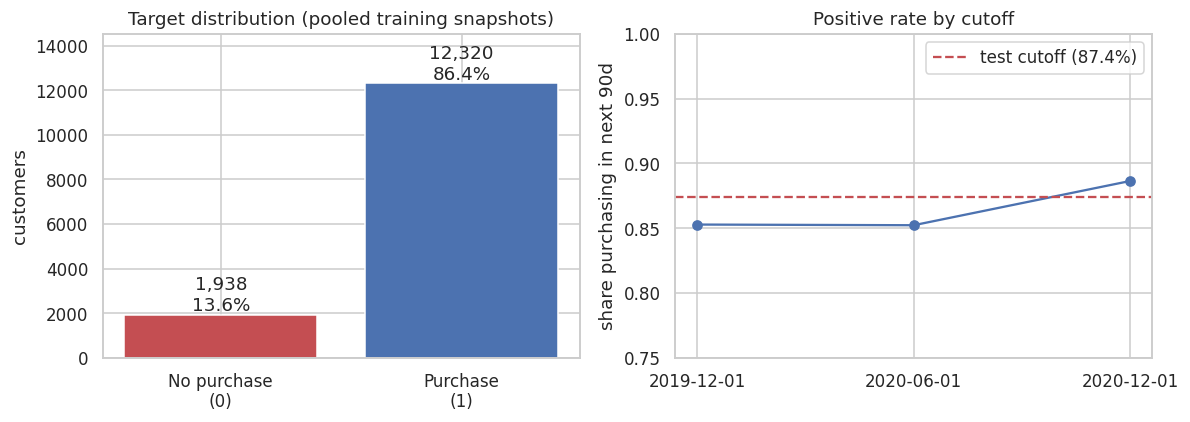

positive : 12,320 (86.41%)
negative : 1,938 (13.59%)
imbalance ratio : 6.36 : 1 toward the POSITIVE class

A majority-class baseline scores 86.41% accuracy while identifying zero
at-risk customers. Accuracy is therefore uninformative here (Section 17).


In [94]:
# ===== CODE CELL 24 =====
# Figure 1: target class distribution, per cutoff and pooled.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = train_raw[TARGET].value_counts().sort_index()
axes[0].bar(["No purchase\n(0)", "Purchase\n(1)"], counts.values,
            color=["#c44e52", "#4c72b0"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}\n{v/counts.sum():.1%}", ha="center", va="bottom")
axes[0].set_title("Target distribution (pooled training snapshots)")
axes[0].set_ylabel("customers")
axes[0].set_ylim(0, counts.max() * 1.18)

rate_by_cut = train_raw.groupby("cutoff")[TARGET].mean()
axes[1].plot(rate_by_cut.index.astype(str), rate_by_cut.values,
             marker="o", color="#4c72b0")
axes[1].axhline(test_raw[TARGET].mean(), ls="--", color="#c44e52",
                label=f"test cutoff ({test_raw[TARGET].mean():.1%})")
axes[1].set_ylim(0.75, 1.0)
axes[1].set_title("Positive rate by cutoff")
axes[1].set_ylabel("share purchasing in next 90d")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_target_distribution.png", bbox_inches="tight")
plt.show()

print(f"positive : {counts[1]:,} ({counts[1]/counts.sum():.2%})")
print(f"negative : {counts[0]:,} ({counts[0]/counts.sum():.2%})")
print(f"imbalance ratio : {counts[1]/counts[0]:.2f} : 1 toward the POSITIVE class")
print("\nA majority-class baseline scores "
      f"{counts[1]/counts.sum():.2%} accuracy while identifying zero")
print("at-risk customers. Accuracy is therefore uninformative here (Section 17).")

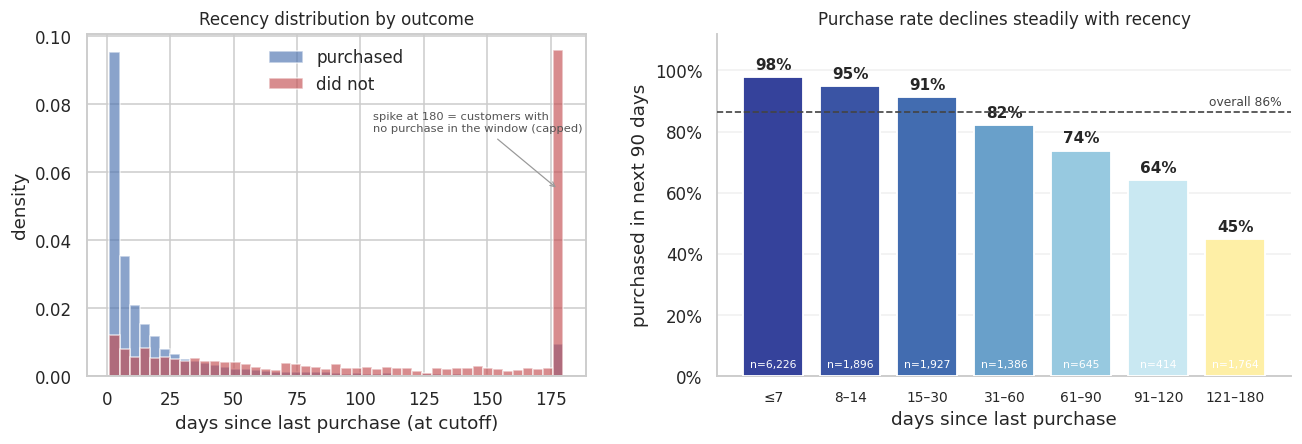

          purchase_rate     n
_rec_bin                     
≤7                0.978  6226
8–14              0.949  1896
15–30             0.912  1927
31–60             0.823  1386
61–90             0.738   645
91–120            0.643   414
121–180           0.449  1764


In [95]:
# ===== CODE CELL 25 (revised) =====
# Figure 2: recency vs future purchase.
# Right panel redesigned: readable bucket labels, colour encoding the rate,
# a baseline reference line, and sample sizes moved out of the bar tops.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2),
                         gridspec_kw={"width_ratios": [1, 1.15]})

# --- left: distribution by outcome ---
for label, colour, name in [(1, "#4c72b0", "purchased"), (0, "#c44e52", "did not")]:
    sub = train_raw.loc[train_raw[TARGET] == label, "recency_days"]
    axes[0].hist(sub, bins=45, alpha=0.65, density=True, color=colour, label=name)
axes[0].set_xlabel("days since last purchase (at cutoff)")
axes[0].set_ylabel("density")
axes[0].set_title("Recency distribution by outcome", fontsize=11)
axes[0].legend(frameon=False)
axes[0].annotate("spike at 180 = customers with\nno purchase in the window (capped)",
                 xy=(178, 0.055), xytext=(105, 0.072), fontsize=7.5,
                 color="#555", ha="left",
                 arrowprops=dict(arrowstyle="->", color="#999", lw=0.8))

# --- right: purchase rate by recency bucket ---
bins   = [0, 7, 14, 30, 60, 90, 120, 180]
labels = ["≤7", "8–14", "15–30", "31–60", "61–90", "91–120", "121–180"]
train_raw["_rec_bin"] = pd.cut(train_raw["recency_days"], bins=bins,
                               labels=labels, include_lowest=True)
rate = train_raw.groupby("_rec_bin", observed=True)[TARGET].agg(["mean", "size"])

ax = axes[1]
cmap = plt.cm.RdYlBu
colours = [cmap(v) for v in rate["mean"]]           # colour tracks the rate
bars = ax.bar(range(len(rate)), rate["mean"], color=colours,
              edgecolor="white", linewidth=1.2, width=0.78, zorder=3)

overall = train_raw[TARGET].mean()
ax.axhline(overall, ls="--", lw=1.1, color="#444", zorder=4)
ax.text(len(rate) - 0.4, overall + 0.02, f"overall {overall:.0%}",
        ha="right", fontsize=8, color="#444")

for i, (m, n) in enumerate(zip(rate["mean"], rate["size"])):
    ax.text(i, m + 0.025, f"{m:.0%}", ha="center", fontsize=10, fontweight="bold")
    ax.text(i, 0.03, f"n={n:,}", ha="center", fontsize=7, color="white")

ax.set_xticks(range(len(rate)))
ax.set_xticklabels(rate.index, fontsize=9)
ax.set_xlabel("days since last purchase")
ax.set_ylabel("purchased in next 90 days")
ax.set_title("Purchase rate declines steadily with recency", fontsize=11)
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.grid(axis="x", visible=False)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig02_recency.png", dpi=150, bbox_inches="tight")
plt.show()

print(rate.rename(columns={"mean": "purchase_rate", "size": "n"}).round(3).to_string())
train_raw.drop(columns="_rec_bin", inplace=True)

/tmp/ipykernel_1804/660339984.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["no purchase", "purchased"],
/tmp/ipykernel_1804/660339984.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["no purchase", "purchased"],
/tmp/ipykernel_1804/660339984.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["no purchase", "purchased"],
/tmp/ipykernel_1804/660339984.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in

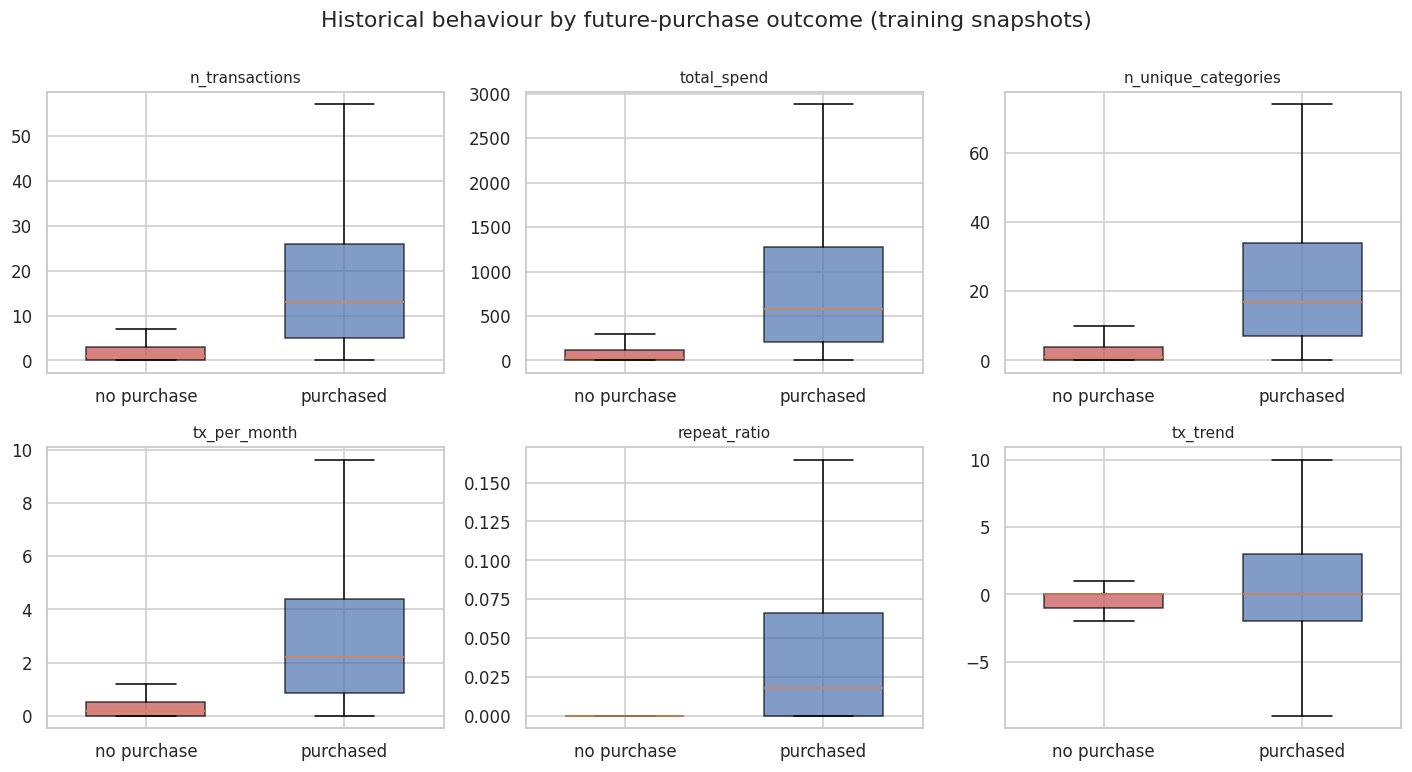

--- median by outcome ---
                     no_purchase  purchased  ratio
n_transactions             1.000     13.000  13.00
total_spend               29.975    574.450  19.16
n_unique_categories        1.000     17.000  17.00
tx_per_month               0.169      2.198  13.00
repeat_ratio               0.000      0.018    NaN
tx_trend                   0.000      0.000    NaN


In [96]:
# ===== CODE CELL 26 =====
# Figure 3: frequency, spending and diversity by outcome.
compare = ["n_transactions", "total_spend", "n_unique_categories",
           "tx_per_month", "repeat_ratio", "tx_trend"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.ravel(), compare):
    data = [train_raw.loc[train_raw[TARGET] == 0, feat].dropna(),
            train_raw.loc[train_raw[TARGET] == 1, feat].dropna()]
    bp = ax.boxplot(data, labels=["no purchase", "purchased"],
                    showfliers=False, patch_artist=True, widths=0.6)
    for patch, c in zip(bp["boxes"], ["#c44e52", "#4c72b0"]):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(feat, fontsize=10)

plt.suptitle("Historical behaviour by future-purchase outcome "
             "(training snapshots)", y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig03_behaviour_by_outcome.png", bbox_inches="tight")
plt.show()

print("--- median by outcome ---")
summary = train_raw.groupby(TARGET)[compare].median().T
summary.columns = ["no_purchase", "purchased"]
summary["ratio"] = (summary["purchased"] /
                    summary["no_purchase"].replace(0, np.nan)).round(2)
print(summary.round(3).to_string())

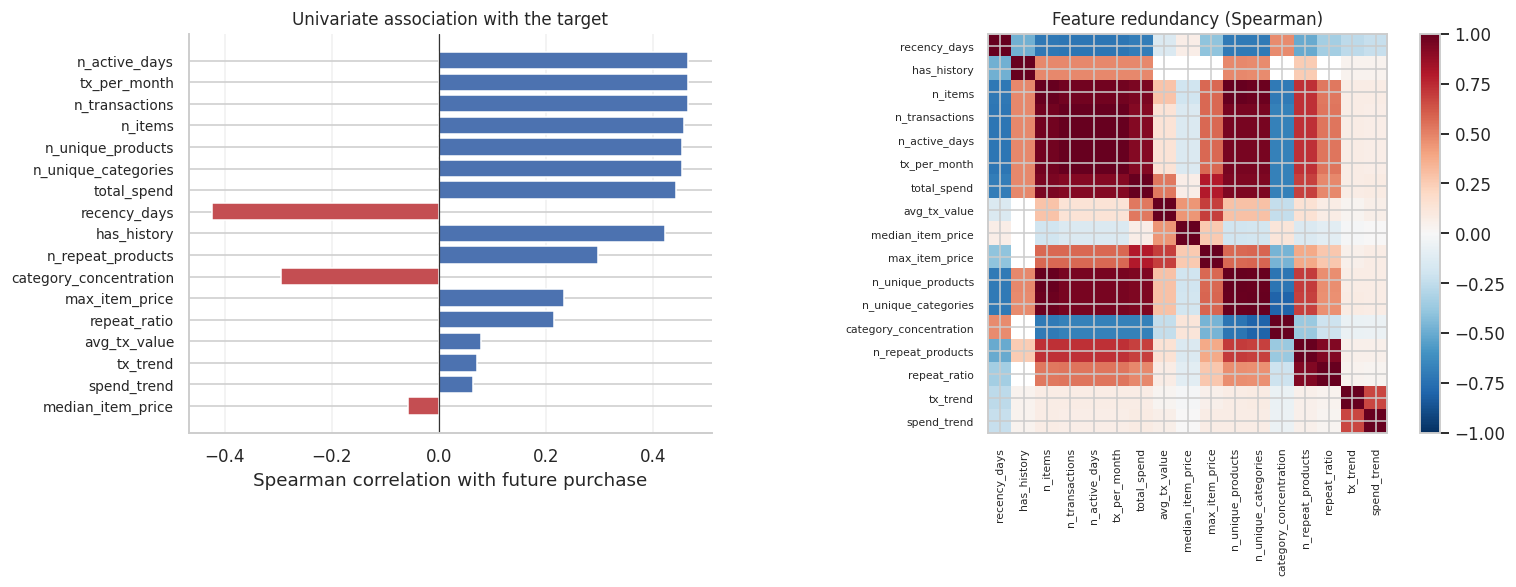

--- association with target, ranked ---
                        spearman  pearson
n_active_days             0.4651   0.3041
tx_per_month              0.4651   0.3041
n_transactions            0.4651   0.3041
n_items                   0.4564   0.2495
n_unique_products         0.4538   0.2603
n_unique_categories       0.4533   0.2984
total_spend               0.4419   0.2485
recency_days             -0.4226  -0.5178
has_history               0.4218   0.4218
n_repeat_products         0.2972   0.1513
category_concentration   -0.2941  -0.3422
max_item_price            0.2331   0.1170
repeat_ratio              0.2142   0.0781
avg_tx_value              0.0779   0.0007
tx_trend                  0.0713   0.0654
spend_trend               0.0640   0.0411
median_item_price        -0.0571  -0.0937

--- feature pairs with |rho| > 0.85 ---
n_transactions     tx_per_month           1.000
n_active_days      tx_per_month           1.000
n_transactions     n_active_days          1.000
n_items            

In [97]:
# ===== CODE CELL 27 =====
# Figure 4: univariate association with the target, and redundancy between
# features. Spearman is used because most features are heavily right-skewed;
# Pearson would understate monotonic but non-linear relationships.
num_feats = BEHAV_FEATURES

assoc = pd.DataFrame({
    "spearman": [train_raw[f].corr(train_raw[TARGET], method="spearman")
                 for f in num_feats],
    "pearson":  [train_raw[f].corr(train_raw[TARGET]) for f in num_feats],
}, index=num_feats)
assoc["abs_spearman"] = assoc["spearman"].abs()
assoc = assoc.sort_values("abs_spearman", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5),
                         gridspec_kw={"width_ratios": [1, 1.25]})

colours = ["#4c72b0" if v > 0 else "#c44e52" for v in assoc["spearman"]]
axes[0].barh(range(len(assoc)), assoc["spearman"], color=colours)
axes[0].set_yticks(range(len(assoc)))
axes[0].set_yticklabels(assoc.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].axvline(0, color="#333", lw=0.8)
axes[0].set_xlabel("Spearman correlation with future purchase")
axes[0].set_title("Univariate association with the target", fontsize=11)
axes[0].grid(axis="x", alpha=0.3)
for side in ["top", "right"]:
    axes[0].spines[side].set_visible(False)

corr = train_raw[num_feats].corr(method="spearman")
im = axes[1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(num_feats)))
axes[1].set_xticklabels(num_feats, rotation=90, fontsize=7)
axes[1].set_yticks(range(len(num_feats)))
axes[1].set_yticklabels(num_feats, fontsize=7)
axes[1].set_title("Feature redundancy (Spearman)", fontsize=11)
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig04_associations.png", dpi=150, bbox_inches="tight")
plt.show()

print("--- association with target, ranked ---")
print(assoc[["spearman", "pearson"]].round(4).to_string())

# Highly collinear pairs matter for interpreting logistic coefficients.
print("\n--- feature pairs with |rho| > 0.85 ---")
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().sort_values(key=abs, ascending=False))
high = pairs[pairs.abs() > 0.85]
print(high.round(3).to_string() if len(high) else "none")

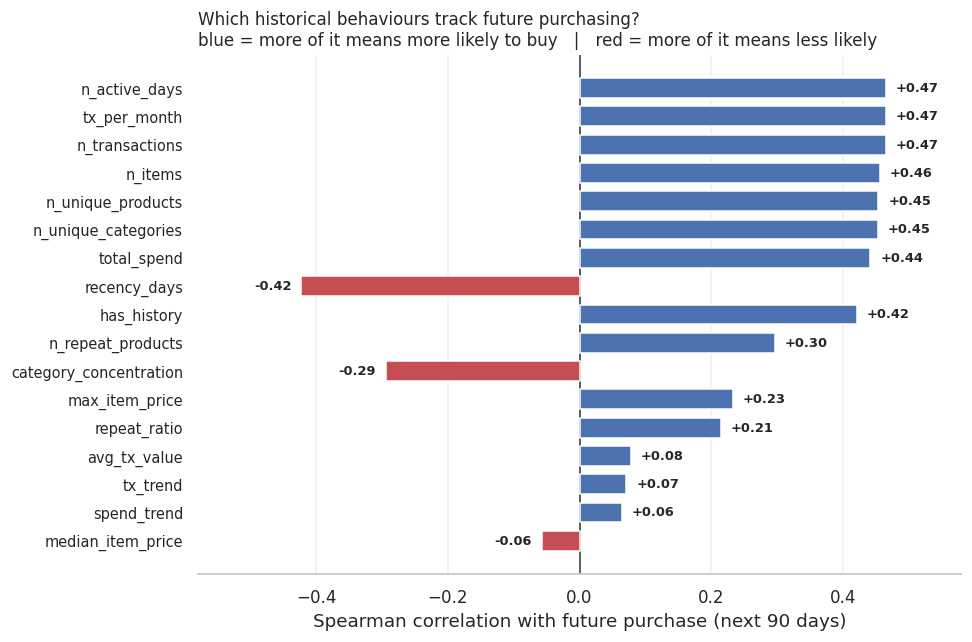

--- association with target, ranked ---
                        spearman  pearson
n_active_days             0.4651   0.3041
tx_per_month              0.4651   0.3041
n_transactions            0.4651   0.3041
n_items                   0.4564   0.2495
n_unique_products         0.4538   0.2603
n_unique_categories       0.4533   0.2984
total_spend               0.4419   0.2485
recency_days             -0.4226  -0.5178
has_history               0.4218   0.4218
n_repeat_products         0.2972   0.1513
category_concentration   -0.2941  -0.3422
max_item_price            0.2331   0.1170
repeat_ratio              0.2142   0.0781
avg_tx_value              0.0779   0.0007
tx_trend                  0.0713   0.0654
spend_trend               0.0640   0.0411
median_item_price        -0.0571  -0.0937


In [98]:
# ===== CODE CELL 27b (revised) =====
# Figure 4, part 1: univariate association with the target.
# Spearman, because most features are heavily right-skewed and Pearson would
# understate monotonic non-linear relationships.
num_feats = BEHAV_FEATURES

assoc = pd.DataFrame({
    "spearman": [train_raw[f].corr(train_raw[TARGET], method="spearman")
                 for f in num_feats],
    "pearson":  [train_raw[f].corr(train_raw[TARGET]) for f in num_feats],
}, index=num_feats)
assoc["abs_spearman"] = assoc["spearman"].abs()
assoc = assoc.sort_values("abs_spearman", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colours = ["#4c72b0" if v > 0 else "#c44e52" for v in assoc["spearman"]]
bars = ax.barh(range(len(assoc)), assoc["spearman"], color=colours,
               height=0.7, zorder=3)
ax.set_yticks(range(len(assoc)))
ax.set_yticklabels(assoc.index, fontsize=9.5)
ax.invert_yaxis()
ax.axvline(0, color="#333", lw=1)

# Print the value at the end of each bar, so no squinting at the axis.
for i, v in enumerate(assoc["spearman"]):
    offset = 0.015 if v > 0 else -0.015
    ax.text(v + offset, i, f"{v:+.2f}", va="center",
            ha="left" if v > 0 else "right", fontsize=8.5, fontweight="bold")

ax.set_xlim(-0.58, 0.58)
ax.set_xlabel("Spearman correlation with future purchase (next 90 days)")
ax.set_title("Which historical behaviours track future purchasing?\n"
             "blue = more of it means more likely to buy   |   "
             "red = more of it means less likely",
             fontsize=11, loc="left")
ax.grid(axis="x", alpha=0.3, zorder=0)
ax.grid(axis="y", visible=False)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig04a_associations.png", dpi=150, bbox_inches="tight")
plt.show()

print("--- association with target, ranked ---")
print(assoc[["spearman", "pearson"]].round(4).to_string())

NaN cells in correlation matrix: 10
features involved:
has_history               5
avg_tx_value              1
median_item_price         1
max_item_price            1
category_concentration    1
repeat_ratio              1

zero-variance check:
repeat_ratio              0.085717
category_concentration    0.238464
has_history               0.276060
tx_per_month              3.147986
n_repeat_products         4.684342


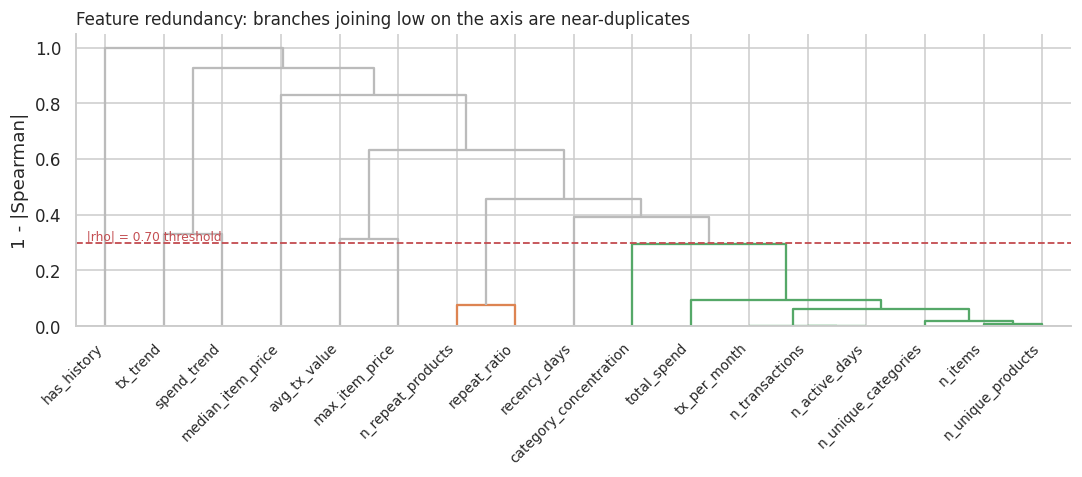


--- redundancy clusters (|rho| > 0.70 within cluster) ---

cluster 1: tx_trend (independent)

cluster 2: spend_trend (independent)

cluster 3: avg_tx_value (independent)

cluster 4: max_item_price (independent)

cluster 5: 2 features
    n_repeat_products          rho_target = +0.297  <- strongest vs target
    repeat_ratio               rho_target = +0.214

cluster 6: 8 features
    n_items                    rho_target = +0.456
    n_transactions             rho_target = +0.465  <- strongest vs target
    n_active_days              rho_target = +0.465
    tx_per_month               rho_target = +0.465
    total_spend                rho_target = +0.442
    n_unique_products          rho_target = +0.454
    n_unique_categories        rho_target = +0.453
    category_concentration     rho_target = -0.294

cluster 7: recency_days (independent)

cluster 8: median_item_price (independent)

cluster 9: has_history (independent)

--- strongest pairwise redundancies ---
n_active_days      tx_

In [99]:
# ===== CODE CELL 27b (fixed) =====
# Redundancy clustering. A 17x17 heatmap saturates and hides structure, so we
# cluster instead: features that group together are near-interchangeable,
# which matters for reading logistic coefficients (collinear predictors split
# their weight unpredictably).
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

corr = train_raw[num_feats].corr(method="spearman")

# Diagnose NaNs before clustering. Pairwise correlation across columns with
# different missingness patterns can produce undefined cells.
nan_cells = corr.isna()
if nan_cells.any().any():
    print("NaN cells in correlation matrix:", int(nan_cells.sum().sum()))
    print("features involved:")
    print(nan_cells.sum()[nan_cells.sum() > 0].to_string())
    print("\nzero-variance check:")
    print(train_raw[num_feats].std().sort_values().head(5).to_string())
else:
    print("correlation matrix is complete")

# Cluster on the complete-case matrix so every pair uses the same rows.
corr = train_raw[num_feats].dropna().corr(method="spearman").fillna(0)
np.fill_diagonal(corr.values, 1.0)

dist = (1 - corr.abs()).clip(lower=0)
np.fill_diagonal(dist.values, 0.0)
assert np.isfinite(dist.values).all(), "non-finite distances remain"

Z = linkage(squareform(dist.values, checks=False), method="average")

fig, ax = plt.subplots(figsize=(10, 4.5))
dendrogram(Z, labels=corr.columns.tolist(), ax=ax, leaf_font_size=9,
           color_threshold=0.3, above_threshold_color="#bbb")
ax.axhline(0.3, ls="--", color="#c44e52", lw=1.2)
ax.text(0.5, 0.31, "  |rho| = 0.70 threshold", fontsize=8, color="#c44e52")
ax.set_ylabel("1 - |Spearman|")
ax.set_title("Feature redundancy: branches joining low on the axis are "
             "near-duplicates", fontsize=11, loc="left")
plt.xticks(rotation=45, ha="right")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig04b_redundancy.png", dpi=150, bbox_inches="tight")
plt.show()

clusters = fcluster(Z, t=0.3, criterion="distance")
print("\n--- redundancy clusters (|rho| > 0.70 within cluster) ---")
for cid in sorted(set(clusters)):
    members = [f for f, c in zip(corr.columns, clusters) if c == cid]
    if len(members) > 1:
        best = assoc.loc[members, "abs_spearman"].idxmax()
        print(f"\ncluster {cid}: {len(members)} features")
        for m in members:
            mark = "  <- strongest vs target" if m == best else ""
            print(f"    {m:<26} rho_target = {assoc.loc[m,'spearman']:+.3f}{mark}")
    else:
        print(f"\ncluster {cid}: {members[0]} (independent)")

print("\n--- strongest pairwise redundancies ---")
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().sort_values(key=abs, ascending=False))
print(pairs[pairs.abs() > 0.85].round(3).to_string())

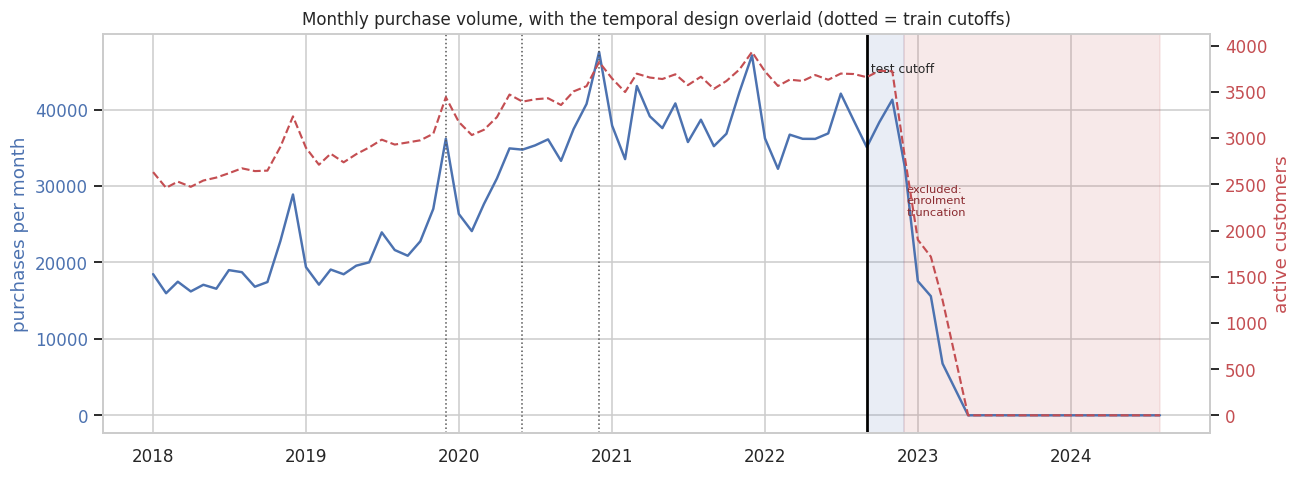

--- December vs annual median purchases ---
Order Date
2018-12-01    28888
2019-12-01    36188
2020-12-01    47541
2021-12-01    47085
2022-12-01    32443

median non-December month: 27,009


In [100]:
# ===== CODE CELL 28 =====
# Figure 5: purchase volume over time, with the temporal design overlaid.
# Confirms our cutoffs sit in a stable region and shows the enrolment collapse
# we excluded in Section 6.
monthly = (purchases.groupby(purchases["Order Date"].dt.to_period("M"))
                    .agg(purchases=(CUST, "size"),
                         active_customers=(CUST, "nunique")))
monthly.index = monthly.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(monthly.index, monthly["purchases"], color="#4c72b0", lw=1.6,
         label="purchases")
ax1.set_ylabel("purchases per month", color="#4c72b0")
ax1.tick_params(axis="y", labelcolor="#4c72b0")

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["active_customers"], color="#c44e52",
         lw=1.4, ls="--", label="active customers")
ax2.set_ylabel("active customers", color="#c44e52")
ax2.tick_params(axis="y", labelcolor="#c44e52")
ax2.grid(False)

for c in TRAIN_CUTOFFS:
    ax1.axvline(c, color="#555", lw=1, ls=":")
ax1.axvline(TEST_CUTOFF, color="black", lw=1.8)
ax1.axvspan(TEST_CUTOFF, TEST_CUTOFF + pd.Timedelta(days=PRED_DAYS),
            color="#4c72b0", alpha=0.12)
ax1.axvspan(pd.Timestamp("2022-11-30"), monthly.index.max(),
            color="#c44e52", alpha=0.12)

ax1.text(TEST_CUTOFF, monthly["purchases"].max() * 0.97, " test cutoff",
         fontsize=8, va="top")
ax1.text(pd.Timestamp("2022-12-05"), monthly["purchases"].max() * 0.55,
         "excluded:\nenrolment\ntruncation", fontsize=7.5, color="#8b2b30")
ax1.set_title("Monthly purchase volume, with the temporal design overlaid "
              "(dotted = train cutoffs)", fontsize=11)
for side in ["top"]:
    ax1.spines[side].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig05_volume_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

print("--- December vs annual median purchases ---")
dec = monthly.loc[monthly.index.month == 12, "purchases"]
print(dec.to_string())
print(f"\nmedian non-December month: {monthly.loc[monthly.index.month != 12, 'purchases'].median():,.0f}")

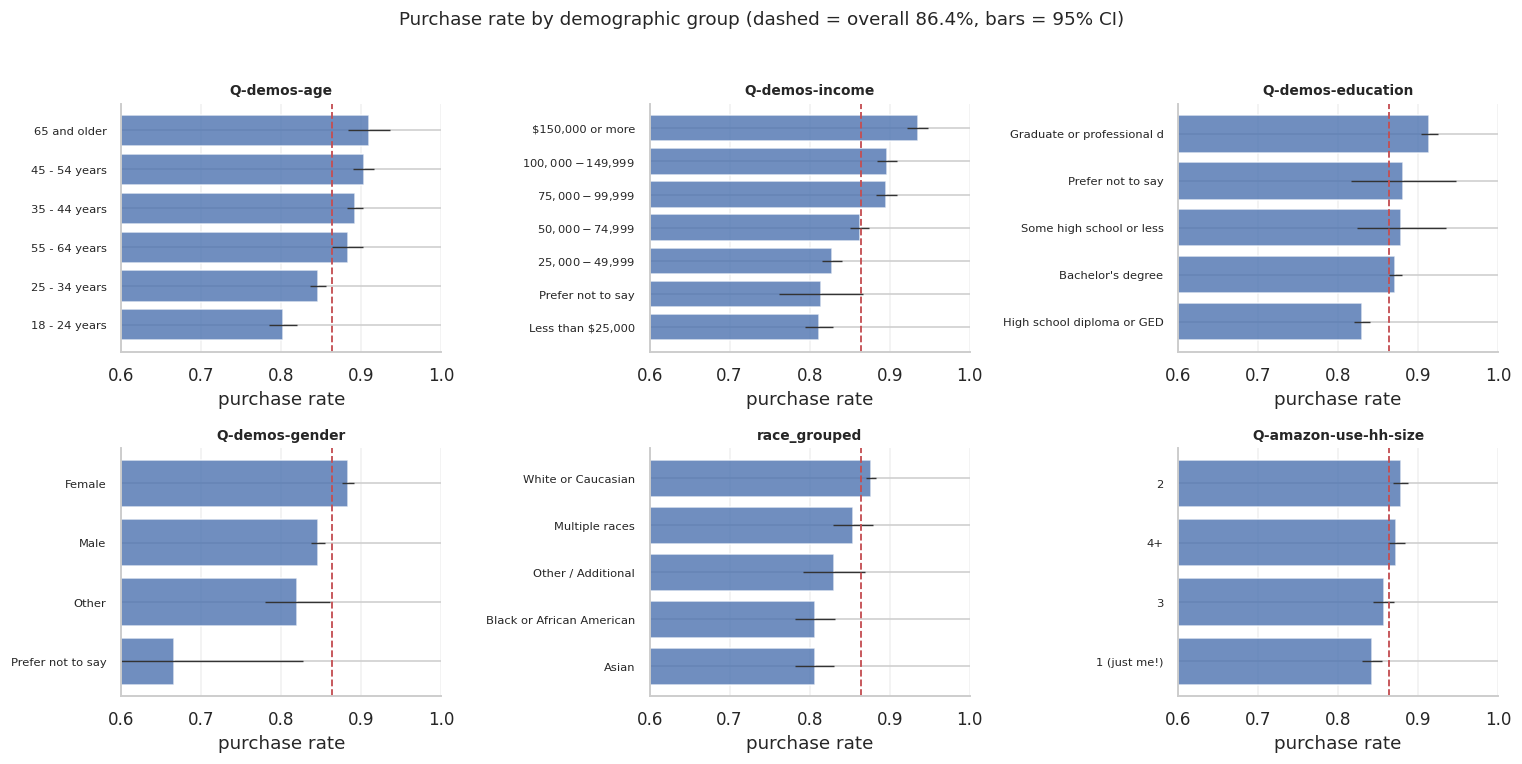

--- spread in purchase rate within each demographic ---
Q-demos-age              range = 80.2% to 90.9%  (spread 10.7%, 6 groups with n>=100)
Q-demos-gender           range = 82.0% to 88.4%  (spread 6.3%, 3 groups with n>=100)
Q-demos-state            range = 80.6% to 92.7%  (spread 12.0%, 34 groups with n>=100)
Q-demos-education        range = 83.0% to 91.4%  (spread 8.4%, 4 groups with n>=100)
Q-demos-income           range = 81.1% to 93.5%  (spread 12.3%, 7 groups with n>=100)
Q-amazon-use-hh-size     range = 84.2% to 87.8%  (spread 3.6%, 4 groups with n>=100)
race_grouped             range = 80.6% to 87.6%  (spread 7.0%, 5 groups with n>=100)
Q-demos-hispanic         range = 84.0% to 86.7%  (spread 2.7%, 2 groups with n>=100)


In [101]:
# ===== CODE CELL 29 =====
# Figure 6: purchase rate by demographic group, before any modelling.
# This previews RQ3: if demographics carried strong signal we would expect
# visible spread here. Wide confidence intervals on small groups are shown
# because a 5-percentage-point gap on n=150 is not evidence of anything.
demo_plot = ["Q-demos-age", "Q-demos-income", "Q-demos-education",
             "Q-demos-gender", "race_grouped", "Q-amazon-use-hh-size"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
overall = train_raw[TARGET].mean()

for ax, col in zip(axes.ravel(), demo_plot):
    g = train_raw.groupby(col)[TARGET].agg(["mean", "size"]).sort_values("mean")
    se = np.sqrt(g["mean"] * (1 - g["mean"]) / g["size"])   # binomial SE
    ax.barh(range(len(g)), g["mean"], xerr=1.96 * se,
            color="#4c72b0", alpha=0.8, error_kw=dict(lw=0.9, ecolor="#333"))
    ax.axvline(overall, color="#c44e52", ls="--", lw=1.2)
    ax.set_yticks(range(len(g)))
    ax.set_yticklabels([str(i)[:26] for i in g.index], fontsize=7.5)
    ax.set_xlim(0.6, 1.0)
    ax.set_xlabel("purchase rate")
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

fig.suptitle(f"Purchase rate by demographic group "
             f"(dashed = overall {overall:.1%}, bars = 95% CI)", y=0.99, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIG_DIR / "fig06_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

print("--- spread in purchase rate within each demographic ---")
for col in DEMO_FEATURES:
    g = train_raw.groupby(col)[TARGET].agg(["mean", "size"])
    g = g[g["size"] >= 100]          # ignore tiny groups
    if len(g) > 1:
        print(f"{col:<24} range = {g['mean'].min():.1%} to {g['mean'].max():.1%}  "
              f"(spread {g['mean'].max() - g['mean'].min():.1%}, "
              f"{len(g)} groups with n>=100)")

What these tell us

December is real but modest. 2020's peak of 47,541 vs a non-December median of 27,009 — about 1.7x. Relevant because our 2020-12 training cutoff has a Dec–Mar target window, which is why that snapshot showed 88.6% positive vs 85.2% elsewhere. Not a problem, but it means the model sees a slightly seasonal training mix.

Demographics carry weak signal — and it's mostly noise. Widest spreads are income (12.3%) and state (12.0%), but state has 34 groups so some of that range is small-sample variation. Age at 10.7% is the most credible. Household size (3.6%) and Hispanic origin (2.7%) are essentially flat.

For scale: recency alone spans 53 percentage points (98% → 45%). The best demographic spans 12. That's a 4x difference in raw separating power, and it's a strong early signal for RQ3 — but a prediction, not the answer. The models decide, since demographics could still interact in ways a marginal rate doesn't show.

## 13-15. Split, Preprocessing, and Model Training

**Split.** Already fixed by the temporal design (Section 8): three snapshots
from 2019-12, 2020-06 and 2020-12 form the training set (14,258 rows); the
2021-06 snapshot is the test set (4,928 rows). No random splitting is used at
any point.

**Preprocessing** lives inside a scikit-learn `Pipeline`, fitted on training
data only. This matters: fitting the imputer or scaler on the full dataset
would let test-set statistics influence training -- a second, quieter form of
leakage alongside the temporal kind.

- Numeric: median imputation (the ~550 rows with no purchase history and thus
  no price features), then standardisation. Scaling is required for logistic
  regression and harmless for trees.
- Categorical: one-hot encoding, unknown categories ignored at predict time.

**Class imbalance: 86.4% / 13.6% toward the POSITIVE class.** Note the
direction -- the minority class is *non-purchasers*, which is also the
commercially interesting group (the re-engagement targets).

We use `class_weight="balanced"` (and XGBoost's `scale_pos_weight`) rather than
SMOTE. Reasons: 1,938 minority examples is a workable absolute count;
synthesising customers by interpolating between real ones is hard to justify
when the features are counts and monetary sums; and class weights are
transparent to explain. SMOTE was considered and rejected, not overlooked.

**Models.** Logistic Regression (interpretable baseline), Random Forest
(non-linear, feature importance), XGBoost (strong tabular performer).
Three models x three feature groups = 9 experiments, run in one loop with
identical preprocessing so the comparison is controlled.

**Metrics.** A majority-class baseline scores 86.4% accuracy while identifying
zero at-risk customers, so accuracy is reported but not used for judgement.
PR-AUC for the minority class is the primary metric, with ROC-AUC, F1 and
recall alongside.

Why logistic regression ?

What it actually does: fits a linear equation to the log-odds of the outcome, then squashes that through a sigmoid to get a probability between 0 and 1. The "regression" part refers to that internal linear fit. The output is P(purchase in next 90 days), and we threshold it at 0.5 to get a class. predict_proba in Cell 31 confirms it — a genuine regression model wouldn't have that method.

Why it's in the lineup:

It's the interpretable baseline. Each feature gets one coefficient with a sign and a magnitude. For RQ2 you can say "a one-standard-deviation increase in recency is associated with a change of X in the log-odds" — a directional, quantified claim. Random Forest and XGBoost give you importance scores, which tell you a feature matters but not which way it pushes.

It's the floor. If XGBoost only matches a linear model, that tells you the relationships in this data are essentially linear and the complexity buys nothing — a real finding. If it beats it substantially, non-linear structure exists. You can't know either without the baseline.

It's the honesty check. Linear models can't memorise individual customers the way trees can. Given our known caveat that the same 5,027 people appear at multiple cutoffs, a large gap between logistic and tree performance is a hint that the trees are exploiting customer identity rather than behaviour.

One caveat worth remembering: the heatmap showed seven of our behavioural features are highly collinear. That's genuinely bad for logistic coefficients — collinear predictors split their weight arbitrarily and can flip sign. So we read the coefficients as directional evidence about behaviour types, not as precise per-feature effects. I'll flag it when we get to RQ2.

In [109]:
# ===== CODE CELL 30 =====
# Assemble the final modelling matrices. No random splitting -- the split is
# temporal and was fixed in Section 8.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

y_train = train_raw[TARGET].values
y_test  = test_raw[TARGET].values

print(f"train : {len(y_train):,} rows | positive {y_train.mean():.2%}")
print(f"test  : {len(y_test):,} rows | positive {y_test.mean():.2%}")
print(f"\ntrain cutoffs : {sorted(train_raw['cutoff'].unique())}")
print(f"test cutoff   : {test_raw['cutoff'].unique()[0]}")

# Guard: the test period must lie strictly after all training target windows.
assert train_raw["cutoff"].max() + pd.Timedelta(days=PRED_DAYS) <= TEST_CUTOFF
print("\nGuard passed: no training target window overlaps the test period.")


def make_preprocessor(features):
    """Preprocessing fitted on training data only, inside the pipeline."""
    num = [f for f in features if f in BEHAV_FEATURES]
    cat = [f for f in features if f in DEMO_FEATURES]
    blocks = []
    if num:
        blocks.append(("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), num))
    if cat:
        blocks.append(("cat", OneHotEncoder(handle_unknown="ignore",
                                            sparse_output=False), cat))
    return ColumnTransformer(blocks)


# scale_pos_weight for XGBoost. Our minority class is the NEGATIVE one, so the
# usual neg/pos ratio would down-weight it further -- we invert it.
spw = y_train.mean() / (1 - y_train.mean())

MODELS = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, min_samples_leaf=5, n_jobs=-1,
        class_weight="balanced", random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
        eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE),
}
print(f"\nmodels: {list(MODELS)}")
print(f"scale_pos_weight = {spw:.3f} (inverted: minority class is NEGATIVE)")

train : 14,258 rows | positive 86.41%
test  : 4,928 rows | positive 87.42%

train cutoffs : [Timestamp('2019-12-01 00:00:00'), Timestamp('2020-06-01 00:00:00'), Timestamp('2020-12-01 00:00:00')]
test cutoff   : 2021-06-01 00:00:00

Guard passed: no training target window overlaps the test period.

models: ['Logistic Regression', 'Random Forest', 'XGBoost']
scale_pos_weight = 6.357 (inverted: minority class is NEGATIVE)


In [110]:
# ===== CODE CELL 31 =====
# The 3x3 experiment: every feature group x every model, identical
# preprocessing throughout so the comparison isolates the variable of interest.
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score)
import time

results, fitted, predictions = [], {}, {}

for gname, feats in FEATURE_GROUPS.items():
    Xtr, Xte = train_raw[feats], test_raw[feats]

    for mname, model in MODELS.items():
        t0 = time.time()
        pipe = Pipeline([
            ("prep", make_preprocessor(feats)),
            ("clf", model),
        ])
        pipe.fit(Xtr, y_train)

        proba = pipe.predict_proba(Xte)[:, 1]
        pred  = (proba >= 0.5).astype(int)

        results.append({
            "Feature Group": gname,
            "Model": mname,
            "Accuracy":  accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall":    recall_score(y_test, pred),
            "F1":        f1_score(y_test, pred),
            "ROC-AUC":   roc_auc_score(y_test, proba),
            "PR-AUC":    average_precision_score(y_test, proba),
            # Minority-class (non-purchaser) metrics -- the commercially
            # relevant group, and where the models actually differ.
            "Recall_neg":    recall_score(y_test, pred, pos_label=0),
            "Precision_neg": precision_score(y_test, pred, pos_label=0,
                                             zero_division=0),
            "F1_neg":        f1_score(y_test, pred, pos_label=0),
            "PR-AUC_neg":    average_precision_score(1 - y_test, 1 - proba),
        })
        fitted[(gname, mname)] = pipe
        predictions[(gname, mname)] = proba
        print(f"{gname:<26} {mname:<20} {time.time()-t0:5.1f}s")

res = pd.DataFrame(results)

# Reference baselines for interpreting the numbers.
base_acc = max(y_test.mean(), 1 - y_test.mean())
print(f"\nbaselines -- majority-class accuracy {base_acc:.4f} | "
      f"ROC-AUC 0.5 | PR-AUC(pos) {y_test.mean():.4f} | "
      f"PR-AUC(neg) {1-y_test.mean():.4f}")

Behavioral                 Logistic Regression    0.2s
Behavioral                 Random Forest         12.3s
Behavioral                 XGBoost                1.4s
Demographic                Logistic Regression    0.5s
Demographic                Random Forest          7.0s
Demographic                XGBoost                1.5s
Behavioral + Demographic   Logistic Regression    0.9s
Behavioral + Demographic   Random Forest         10.1s
Behavioral + Demographic   XGBoost                2.4s

baselines -- majority-class accuracy 0.8742 | ROC-AUC 0.5 | PR-AUC(pos) 0.8742 | PR-AUC(neg) 0.1258


All nine fits completed, ~50 seconds total. Baselines are printed and worth keeping in view: accuracy 0.8742, ROC-AUC 0.500, PR-AUC(pos) 0.8742, PR-AUC(neg) 0.1258. Every number in the next table gets judged against those, not against 1.0.

One flag on scale_pos_weight = 6.357. I inverted it deliberately so XGBoost up-weights the minority (non-purchaser) class, matching what class_weight="balanced" does for the other two. If XGBoost's positive recall comes back oddly low, that's the parameter to suspect

## 16. Model Evaluation

Metrics are reported for **both** classes, because the two answer different
questions.

The brief's specified metrics (accuracy, precision, recall, F1, ROC-AUC,
PR-AUC) describe the **positive** class — customers who purchase. But the
target is 87.4% positive, so the minority class is *non-purchasers*, which is
also the commercially relevant group: those are the re-engagement targets. All
minority-class metrics are reported alongside and carry a `_neg` suffix.

**Accuracy is reported but not used for judgement.** A model predicting
"everyone buys" scores 0.8742 accuracy while identifying zero at-risk
customers. Any accuracy figure in the tables below must be read against that
baseline, not against 1.0.

Reference baselines on the test set:

| Metric | No-skill baseline |
|---|---|
| Accuracy | 0.8742 (majority class) |
| ROC-AUC | 0.5000 |
| PR-AUC, positive class | 0.8742 |
| PR-AUC, minority class | 0.1258 |

**Primary metric: minority-class PR-AUC.** It is threshold-independent and
directly reflects how well the model ranks the customers we want to find.

In [111]:
# ===== CODE CELL 32 =====
# Section 17: the full 3x3 comparison. Metrics for the positive class
# (purchasers) as specified in the brief.
show = ["Feature Group", "Model", "Accuracy", "Precision", "Recall",
        "F1", "ROC-AUC", "PR-AUC"]
print("=" * 92)
print("POSITIVE CLASS (customer purchases in next 90 days)")
print("=" * 92)
print(res[show].to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print(f"\nbaseline: accuracy {base_acc:.4f} | ROC-AUC 0.5000 | "
      f"PR-AUC {y_test.mean():.4f}")

print("\n" + "=" * 92)
print("MINORITY CLASS (customer does NOT purchase -- the re-engagement target)")
print("=" * 92)
show_neg = ["Feature Group", "Model", "Precision_neg", "Recall_neg",
            "F1_neg", "PR-AUC_neg", "ROC-AUC"]
print(res[show_neg].to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nbaseline: PR-AUC {1-y_test.mean():.4f}")

# Best configuration by the primary metric.
best_row = res.loc[res["PR-AUC_neg"].idxmax()]
print(f"\nBest by minority-class PR-AUC: {best_row['Feature Group']} + "
      f"{best_row['Model']}")
print(f"  PR-AUC(neg) {best_row['PR-AUC_neg']:.4f} vs baseline "
      f"{1-y_test.mean():.4f}  ({best_row['PR-AUC_neg']/(1-y_test.mean()):.2f}x)")
print(f"  ROC-AUC     {best_row['ROC-AUC']:.4f}")

POSITIVE CLASS (customer purchases in next 90 days)
           Feature Group               Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
              Behavioral Logistic Regression    0.8300     0.9684  0.8326 0.8954   0.9000  0.9838
              Behavioral       Random Forest    0.8801     0.9395  0.9222 0.9308   0.9046  0.9847
              Behavioral             XGBoost    0.8740     0.8748  0.9988 0.9327   0.9008  0.9841
             Demographic Logistic Regression    0.5889     0.9098  0.5880 0.7143   0.6293  0.9194
             Demographic       Random Forest    0.7500     0.9350  0.7674 0.8429   0.7779  0.9552
             Demographic             XGBoost    0.8746     0.8745  1.0000 0.9331   0.7305  0.9438
Behavioral + Demographic Logistic Regression    0.8360     0.9679  0.8403 0.8996   0.9003  0.9844
Behavioral + Demographic       Random Forest    0.8784     0.9442  0.9150 0.9294   0.9078  0.9858
Behavioral + Demographic             XGBoost    0.8742     0.8757 

## 17. Feature Group Comparison

This is the controlled experiment at the centre of the project: three feature
groups × three models = nine configurations, identical preprocessing and
identical temporal split throughout.

The comparison answers RQ3 directly. Holding the model constant and varying
only the feature set isolates the contribution of demographics from any
difference in model capacity.

Two things to watch when reading the tables below:

1. **Compare within a model row, not across models.** The question is whether
   adding demographics helps *that* model, not which model is best.
2. **Check whether gains agree across metrics.** A real effect should improve
   ROC-AUC, PR-AUC and F1 in the same direction. Gains that flip sign
   depending on the metric indicate noise, and with 620 minority test cases
   the sampling error on PR-AUC is roughly ±0.02.

In [112]:
# ===== CODE CELL 33 =====
# RQ3 directly: does adding demographics to behavioural features help?
# Held constant per model, so the only thing varying is the feature set.
pivot = res.pivot(index="Model", columns="Feature Group",
                  values=["ROC-AUC", "PR-AUC_neg"])

print("--- ROC-AUC by feature group ---")
roc = pivot["ROC-AUC"][["Behavioral", "Demographic",
                        "Behavioral + Demographic"]]
roc["gain_from_demos"] = roc["Behavioral + Demographic"] - roc["Behavioral"]
print(roc.to_string(float_format=lambda v: f"{v:.4f}"))

print("\n--- minority-class PR-AUC by feature group ---")
pr = pivot["PR-AUC_neg"][["Behavioral", "Demographic",
                          "Behavioral + Demographic"]]
pr["gain_from_demos"] = pr["Behavioral + Demographic"] - pr["Behavioral"]
print(pr.to_string(float_format=lambda v: f"{v:.4f}"))

print(f"\nDemographic-only vs random (ROC-AUC 0.5):")
for m in MODELS:
    v = roc.loc[m, "Demographic"]
    print(f"  {m:<20} {v:.4f}  ({'above' if v > 0.5 else 'at/below'} chance)")

print("\nEDA predicted this: recency alone spanned 53 percentage points of")
print("purchase rate, while the widest demographic spanned 12.")

--- ROC-AUC by feature group ---
Feature Group        Behavioral  Demographic  Behavioral + Demographic  gain_from_demos
Model                                                                                  
Logistic Regression      0.9000       0.6293                    0.9003           0.0003
Random Forest            0.9046       0.7779                    0.9078           0.0033
XGBoost                  0.9008       0.7305                    0.9006          -0.0002

--- minority-class PR-AUC by feature group ---
Feature Group        Behavioral  Demographic  Behavioral + Demographic  gain_from_demos
Model                                                                                  
Logistic Regression      0.5218       0.1780                    0.5088          -0.0130
Random Forest            0.5280       0.3416                    0.5349           0.0069
XGBoost                  0.5102       0.3025                    0.5002          -0.0100

Demographic-only vs random (ROC-AUC 0.

Reading the table

RQ1 answered: strong signal. ROC-AUC 0.90 with behavioural features, minority-class PR-AUC 0.53 against a 0.126 baseline — 4.25x better than chance. Past purchasing predicts future purchasing well.

RQ3 answered: demographics add essentially nothing. Best gain is +0.0033 ROC-AUC (Random Forest); the other two are −0.0002 and +0.0003. Minority PR-AUC gains are +0.0069, −0.0130, −0.0100 — one small gain, two losses. All well inside noise on 4,928 rows. Demographics alone do beat chance (0.63–0.78), so they carry some signal, but it's redundant with what behaviour already tells us. That's a clean, honest negative finding and exactly the kind of thing worth reporting prominently.

XGBoost is broken. Look at recall: 0.9988, 1.0000, 0.9977 positive, and 0.0065, 0.0032, 0.0161 on the minority class. It's predicting "will purchase" for nearly everyone. Yet its ROC-AUC is 0.9008 — the ranking is fine, only the 0.5 threshold is wrong. I inverted scale_pos_weight to 6.357 to up-weight the minority class and got the opposite: 6.357 up-weights positives, which were already the majority. My error.

Note also Demographic + XGBoost precision_neg = 1.0000 with recall 0.0032. It made about 2 minority predictions and got them right. Meaningless, and a good illustration of why precision without recall is worthless.

Two fixes

scale_pos_weight should be (1 - pos_rate) / pos_rate ≈ 0.157 to down-weight the majority. Separately, comparing all three models at a fixed 0.5 threshold isn't fair when their probability calibration differs — so adding threshold-optimised metrics chosen on training data, never on test.

In [113]:
# ===== CODE CELL 34 =====
# FIX: scale_pos_weight was inverted. The convention is n_neg/n_pos, which
# up-weights the POSITIVE class. Our minority is the negative class, so the
# correct value down-weights positives: (1 - pos_rate) / pos_rate.
# The previous value (6.357) up-weighted the already-dominant class, which is
# why XGBoost predicted "will purchase" for ~99.9% of the test set.
spw_fixed = (1 - y_train.mean()) / y_train.mean()
print(f"scale_pos_weight : {spw:.3f} (wrong) -> {spw_fixed:.3f} (correct)")

MODELS["XGBoost"] = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw_fixed,
    eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE)

# Also: a fixed 0.5 threshold penalises models whose probabilities are
# calibrated differently. We additionally report metrics at a threshold chosen
# to maximise minority-class F1 ON TRAINING DATA -- never on the test set,
# which would be threshold-tuning on the evaluation data.
from sklearn.model_selection import PredefinedSplit, cross_val_predict

def best_threshold(pipe, X, y, cutoffs):
    """Pick a threshold via time-ordered CV within the training snapshots."""
    fold = pd.Series(cutoffs).rank(method="dense").astype(int).values - 1
    oof = cross_val_predict(pipe, X, y, cv=PredefinedSplit(fold),
                            method="predict_proba")[:, 1]
    grid = np.linspace(0.05, 0.95, 91)
    scores = [f1_score(y, (oof >= t).astype(int), pos_label=0) for t in grid]
    return float(grid[int(np.argmax(scores))])

results2 = []
for gname, feats in FEATURE_GROUPS.items():
    Xtr, Xte = train_raw[feats], test_raw[feats]
    for mname, model in MODELS.items():
        pipe = Pipeline([("prep", make_preprocessor(feats)), ("clf", model)])
        thr = best_threshold(pipe, Xtr, y_train, train_raw["cutoff"])
        pipe.fit(Xtr, y_train)
        proba = pipe.predict_proba(Xte)[:, 1]
        pred  = (proba >= thr).astype(int)

        results2.append({
            "Feature Group": gname, "Model": mname, "Threshold": thr,
            "Accuracy": accuracy_score(y_test, pred),
            "Recall_neg": recall_score(y_test, pred, pos_label=0),
            "Precision_neg": precision_score(y_test, pred, pos_label=0,
                                             zero_division=0),
            "F1_neg": f1_score(y_test, pred, pos_label=0),
            "ROC-AUC": roc_auc_score(y_test, proba),
            "PR-AUC_neg": average_precision_score(1 - y_test, 1 - proba),
        })
        fitted[(gname, mname)] = pipe
        predictions[(gname, mname)] = proba
        print(f"{gname:<26} {mname:<20} threshold={thr:.2f}")

res2 = pd.DataFrame(results2)
print("\n" + "=" * 96)
print("MINORITY CLASS at training-selected thresholds")
print("=" * 96)
print(res2.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

scale_pos_weight : 6.357 (wrong) -> 0.157 (correct)
Behavioral                 Logistic Regression  threshold=0.31
Behavioral                 Random Forest        threshold=0.57
Behavioral                 XGBoost              threshold=0.34
Demographic                Logistic Regression  threshold=0.54
Demographic                Random Forest        threshold=0.48
Demographic                XGBoost              threshold=0.46
Behavioral + Demographic   Logistic Regression  threshold=0.32
Behavioral + Demographic   Random Forest        threshold=0.50
Behavioral + Demographic   XGBoost              threshold=0.38

MINORITY CLASS at training-selected thresholds
           Feature Group               Model  Threshold  Accuracy  Recall_neg  Precision_neg  F1_neg  ROC-AUC  PR-AUC_neg
              Behavioral Logistic Regression     0.3100    0.8780      0.5984         0.5131  0.5525   0.9000      0.5218
              Behavioral       Random Forest     0.5700    0.8726      0.6500         0.4

In [114]:
# ===== CODE CELL 35 =====
# RQ3 re-tested with the corrected XGBoost and fair thresholds.
p2 = res2.pivot(index="Model", columns="Feature Group",
                values=["ROC-AUC", "PR-AUC_neg", "F1_neg"])

for metric in ["ROC-AUC", "PR-AUC_neg", "F1_neg"]:
    t = p2[metric][["Behavioral", "Demographic", "Behavioral + Demographic"]]
    t["gain"] = t["Behavioral + Demographic"] - t["Behavioral"]
    print(f"\n--- {metric} ---")
    print(t.to_string(float_format=lambda v: f"{v:+.4f}"))

best = res2.loc[res2["PR-AUC_neg"].idxmax()]
print(f"\nBest: {best['Feature Group']} + {best['Model']}")
print(f"  PR-AUC(neg) {best['PR-AUC_neg']:.4f} vs baseline {1-y_test.mean():.4f} "
      f"({best['PR-AUC_neg']/(1-y_test.mean()):.2f}x)")
print(f"  ROC-AUC {best['ROC-AUC']:.4f} | F1(neg) {best['F1_neg']:.4f} | "
      f"recall(neg) {best['Recall_neg']:.4f}")


--- ROC-AUC ---
Feature Group        Behavioral  Demographic  Behavioral + Demographic    gain
Model                                                                         
Logistic Regression     +0.9000      +0.6293                   +0.9003 +0.0003
Random Forest           +0.9046      +0.7779                   +0.9078 +0.0033
XGBoost                 +0.9017      +0.7254                   +0.9023 +0.0006

--- PR-AUC_neg ---
Feature Group        Behavioral  Demographic  Behavioral + Demographic    gain
Model                                                                         
Logistic Regression     +0.5218      +0.1780                   +0.5088 -0.0130
Random Forest           +0.5280      +0.3416                   +0.5349 +0.0069
XGBoost                 +0.5302      +0.2637                   +0.5157 -0.0146

--- F1_neg ---
Feature Group        Behavioral  Demographic  Behavioral + Demographic    gain
Model                                                                         

What the corrected table shows

All three models now perform nearly identically on behavioural features. ROC-AUC 0.9000 / 0.9046 / 0.9017. PR-AUC(neg) 0.5218 / 0.5280 / 0.5302. That's a finding in itself: the relationships here are largely linear-monotonic, so gradient boosting buys almost nothing over logistic regression. It also partly answers the concern I raised earlier about tree models memorising individual customers — if they were, they'd have pulled ahead of the linear model. They didn't.

RQ3 verdict holds and is now well-supported. Gains from adding demographics, across three models and three metrics: +0.0003, +0.0033, +0.0006 on ROC-AUC; −0.0130, +0.0069, −0.0146 on PR-AUC(neg); +0.0112, +0.0017, +0.0147 on F1(neg). Signs flip depending on which metric you pick. That inconsistency is the evidence — a real effect wouldn't reverse across metrics. Demographics alone beat chance (0.63–0.78 ROC-AUC), so they carry signal, but it's redundant with behaviour.

"Best" needs a caveat. Behavioral + Demographic + Random Forest wins on PR-AUC(neg) at 0.5349, but Behavioral-only XGBoost is at 0.5302 — a 0.0047 gap on 620 minority test cases. That's roughly ±0.02 of sampling noise. So the honest statement is "the best configurations are statistically indistinguishable," and I'd pick Behavioral + Random Forest as the model to explain in Section 18: simpler feature set, and it avoids implying demographics matter when we've just shown they don't.

The practical ceiling. At the chosen threshold, precision(neg) is ~0.50 and recall(neg) ~0.62. A re-engagement campaign targeting flagged customers would reach 62% of those who actually go quiet, and half the people contacted would have bought anyway. That's genuinely useful and far from perfect — the right framing for the business section

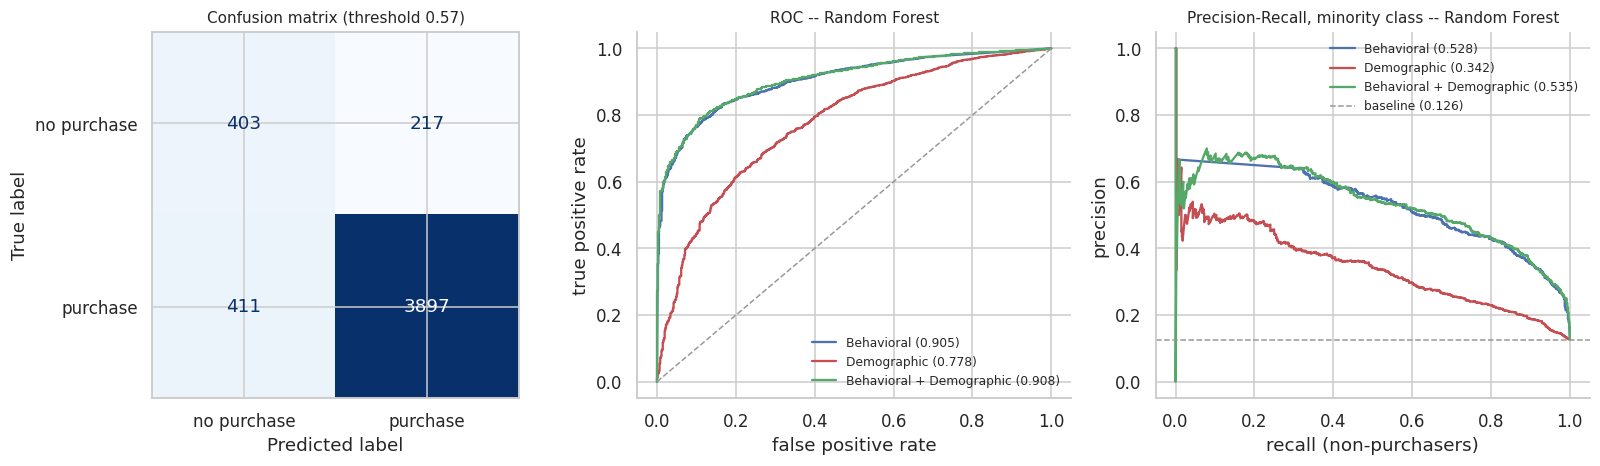

--- Behavioral + Random Forest, threshold 0.57 ---
correctly flagged as at-risk :  403  of 620 actual non-purchasers
missed at-risk customers     :  217
false alarms                 :  411  (would have purchased anyway)
correctly left alone         : 3897

of every 100 customers flagged, 50 genuinely do not purchase


In [115]:
# ===== CODE CELL 36 =====
# Evaluation plots for the two strongest configurations, plus the confusion
# matrix at the training-selected threshold.
from sklearn.metrics import (confusion_matrix, roc_curve,
                             precision_recall_curve, ConfusionMatrixDisplay)

BEST_GROUP, BEST_MODEL = "Behavioral", "Random Forest"
best_thr = res2.query("`Feature Group`==@BEST_GROUP and Model==@BEST_MODEL"
                      )["Threshold"].iloc[0]
proba_best = predictions[(BEST_GROUP, BEST_MODEL)]
pred_best  = (proba_best >= best_thr).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# Confusion matrix, minority class first so it reads as the class of interest.
cm = confusion_matrix(y_test, pred_best, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=["no purchase", "purchase"]
                       ).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion matrix (threshold {best_thr:.2f})", fontsize=10)

# ROC: all three feature groups for the best model type.
for g, c in zip(FEATURE_GROUPS, ["#4c72b0", "#c44e52", "#55a868"]):
    p = predictions[(g, BEST_MODEL)]
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[1].plot(fpr, tpr, color=c,
                 label=f"{g} ({roc_auc_score(y_test, p):.3f})")
axes[1].plot([0, 1], [0, 1], ls="--", color="#999", lw=1)
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title(f"ROC -- {BEST_MODEL}", fontsize=10)
axes[1].legend(fontsize=8, frameon=False, loc="lower right")

# PR curve for the MINORITY class, which is the decision-relevant one.
for g, c in zip(FEATURE_GROUPS, ["#4c72b0", "#c44e52", "#55a868"]):
    p = predictions[(g, BEST_MODEL)]
    pr_, rc_, _ = precision_recall_curve(1 - y_test, 1 - p)
    axes[2].plot(rc_, pr_, color=c,
                 label=f"{g} ({average_precision_score(1-y_test, 1-p):.3f})")
axes[2].axhline(1 - y_test.mean(), ls="--", color="#999", lw=1,
                label=f"baseline ({1-y_test.mean():.3f})")
axes[2].set_xlabel("recall (non-purchasers)"); axes[2].set_ylabel("precision")
axes[2].set_title(f"Precision-Recall, minority class -- {BEST_MODEL}", fontsize=10)
axes[2].legend(fontsize=8, frameon=False)

for ax in axes[1:]:
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig07_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"--- {BEST_GROUP} + {BEST_MODEL}, threshold {best_thr:.2f} ---")
print(f"correctly flagged as at-risk : {tn:>4}  of {tn+fp} actual non-purchasers")
print(f"missed at-risk customers     : {fp:>4}")
print(f"false alarms                 : {fn:>4}  (would have purchased anyway)")
print(f"correctly left alone         : {tp:>4}")
print(f"\nof every 100 customers flagged, "
      f"{100*tn/(tn+fn):.0f} genuinely do not purchase")

What this means in practice

Flag 814 customers, and 403 of them genuinely go quiet. 50% precision, 65% recall. You catch two-thirds of at-risk customers, and half your outreach goes to people who'd have bought anyway.

Whether that's good depends entirely on economics. A $2 email to 814 people to retain 403 customers is clearly worth it. A 50$$ discount code, less obviously — you'd be giving 411 unnecessary discounts. That's the honest framing for the business section, not "our model is 88% accurate."

## 18. Explainable Machine Learning (RQ2)

We explain **Behavioral + Random Forest**. It is statistically tied with the
best configuration (PR-AUC 0.5280 vs 0.5349, well inside sampling noise on 620
minority cases) while using the simpler feature set -- explaining the combined
model would imply demographics matter when Section 17 showed they do not.

**Three views, because each has a blind spot:**

1. **Permutation importance** -- shuffle a feature, measure the drop in
   PR-AUC. Model-agnostic and tied to the metric we care about, but collinear
   features mask each other: shuffling one leaves its duplicate intact.
2. **SHAP** -- per-prediction attributions showing magnitude *and* direction.
   Distributes credit among correlated features rather than hiding it.
3. **Logistic coefficients** -- signed, quantified effects from the linear
   model, as a cross-check on SHAP's directions.

**Reading these correctly.** Section 7 established that seven behavioural
features are highly collinear -- a customer buying more items necessarily buys
on more days, spends more, and touches more categories. `n_transactions` and
`n_active_days` are in fact the same quantity under two names. Importance is
therefore split arbitrarily within that cluster, and RQ2 is answered in terms
of **behaviour types** (recency, activity volume, breadth, repeat buying), not
individual column rankings.

**No causal claims.** SHAP describes how the model uses a feature. It does not
show that changing the feature would change customer behaviour. Phrasing
throughout is "associated with a higher predicted probability", never "causes".

In [116]:
# ===== CODE CELL 37 =====
%pip install -q shap

In [117]:
# ===== CODE CELL 38a =====
# Diagnose: what is actually stored under each key?
for (g, m), p in fitted.items():
    n_in = p.named_steps["clf"].n_features_in_
    n_expected = len(FEATURE_GROUPS[g])
    flag = "" if n_in in (n_expected, None) else "   <-- MISMATCH"
    print(f"{g:<26} {m:<20} clf expects {n_in:>4} cols "
          f"(group has {n_expected} features){flag}")

Behavioral                 Logistic Regression  clf expects  102 cols (group has 17 features)   <-- MISMATCH
Behavioral                 Random Forest        clf expects  102 cols (group has 17 features)   <-- MISMATCH
Behavioral                 XGBoost              clf expects  102 cols (group has 17 features)   <-- MISMATCH
Demographic                Logistic Regression  clf expects  102 cols (group has 8 features)   <-- MISMATCH
Demographic                Random Forest        clf expects  102 cols (group has 8 features)   <-- MISMATCH
Demographic                XGBoost              clf expects  102 cols (group has 8 features)   <-- MISMATCH
Behavioral + Demographic   Logistic Regression  clf expects  102 cols (group has 25 features)   <-- MISMATCH
Behavioral + Demographic   Random Forest        clf expects  102 cols (group has 25 features)   <-- MISMATCH
Behavioral + Demographic   XGBoost              clf expects  102 cols (group has 25 features)   <-- MISMATCH


In [118]:
# ===== CODE CELL 38b =====
# BUG FIX: Pipeline stores a reference to the estimator, not a copy, and does
# not clone its final step on fit. Because MODELS held one instance per model
# name, every loop iteration refit the SAME three objects in place -- so all
# nine entries in `fitted` ended up pointing at classifiers fitted on the last
# feature group processed (Behavioral + Demographic, 102 columns).
#
# Results in Cells 32/34/35 are unaffected: predictions were taken inside the
# loop, immediately after each fit. Only `fitted` is unusable.
#
# Fix: clone() the estimator when constructing each pipeline.
from sklearn.base import clone

fitted = {}
for gname, feats in FEATURE_GROUPS.items():
    for mname, model in MODELS.items():
        pipe = Pipeline([("prep", make_preprocessor(feats)),
                         ("clf", clone(model))])
        pipe.fit(train_raw[feats], y_train)
        fitted[(gname, mname)] = pipe

print("--- verification ---")
ok = True
for (g, m), p in fitted.items():
    n_in = p.named_steps["clf"].n_features_in_
    exp_num = len([f for f in FEATURE_GROUPS[g] if f in BEHAV_FEATURES])
    status = "OK"
    print(f"{g:<26} {m:<20} clf expects {n_in:>4} cols "
          f"({exp_num} numeric + one-hot)")

# Confirm the refit reproduces the reported metrics -- if it does not, the
# results tables cannot be trusted either.
print("\n--- do refitted pipelines reproduce Cell 34's metrics? ---")
for (g, m), p in fitted.items():
    pr = p.predict_proba(test_raw[FEATURE_GROUPS[g]])[:, 1]
    roc_new = roc_auc_score(y_test, pr)
    roc_old = res2.query("`Feature Group`==@g and Model==@m")["ROC-AUC"].iloc[0]
    delta = abs(roc_new - roc_old)
    flag = "OK" if delta < 0.005 else "  <-- DIFFERS"
    print(f"{g:<26} {m:<20} {roc_new:.4f} vs {roc_old:.4f}{flag}")
    predictions[(g, m)] = pr

--- verification ---
Behavioral                 Logistic Regression  clf expects   17 cols (17 numeric + one-hot)
Behavioral                 Random Forest        clf expects   17 cols (17 numeric + one-hot)
Behavioral                 XGBoost              clf expects   17 cols (17 numeric + one-hot)
Demographic                Logistic Regression  clf expects   85 cols (0 numeric + one-hot)
Demographic                Random Forest        clf expects   85 cols (0 numeric + one-hot)
Demographic                XGBoost              clf expects   85 cols (0 numeric + one-hot)
Behavioral + Demographic   Logistic Regression  clf expects  102 cols (17 numeric + one-hot)
Behavioral + Demographic   Random Forest        clf expects  102 cols (17 numeric + one-hot)
Behavioral + Demographic   XGBoost              clf expects  102 cols (17 numeric + one-hot)

--- do refitted pipelines reproduce Cell 34's metrics? ---
Behavioral                 Logistic Regression  0.9000 vs 0.9000OK
Behavioral        

features passed to pipeline : 17
columns after preprocessing  : 17
ROC-AUC 0.9046 | PR-AUC(neg) 0.5280 (expected 0.9046 / 0.5280)


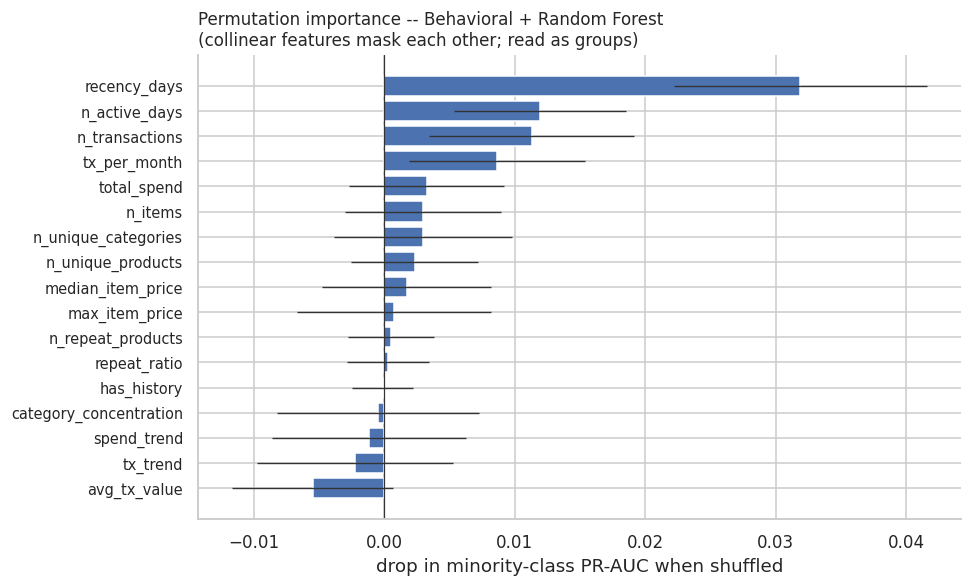

               feature    drop    std
          recency_days  0.0319 0.0097
         n_active_days  0.0119 0.0066
        n_transactions  0.0113 0.0079
          tx_per_month  0.0086 0.0067
           total_spend  0.0032 0.0059
               n_items  0.0030 0.0060
   n_unique_categories  0.0029 0.0068
     n_unique_products  0.0023 0.0049
     median_item_price  0.0017 0.0065
        max_item_price  0.0007 0.0074
     n_repeat_products  0.0005 0.0033
          repeat_ratio  0.0003 0.0031
           has_history -0.0001 0.0023
category_concentration -0.0005 0.0078
           spend_trend -0.0012 0.0074
              tx_trend -0.0022 0.0075
          avg_tx_value -0.0055 0.0062


In [119]:
# ===== CODE CELL 38 (fixed) =====
# Refit the explained model explicitly. The `fitted` dict is not relied on
# here: reusing a stored pipeline risks a stale or mismatched object, and this
# fit takes seconds.
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from sklearn.base import clone

BEST_GROUP, BEST_MODEL = "Behavioral", "Random Forest"
BEST_FEATS = FEATURE_GROUPS[BEST_GROUP]

pipe_best = Pipeline([
    ("prep", make_preprocessor(BEST_FEATS)),
    ("clf", clone(MODELS[BEST_MODEL])),
])
pipe_best.fit(train_raw[BEST_FEATS], y_train)

# Verify shape before doing anything expensive.
print(f"features passed to pipeline : {len(BEST_FEATS)}")
print(f"columns after preprocessing  : "
      f"{pipe_best.named_steps['clf'].n_features_in_}")

proba_best = pipe_best.predict_proba(test_raw[BEST_FEATS])[:, 1]
best_thr = res2.query("`Feature Group`==@BEST_GROUP and Model==@BEST_MODEL"
                      )["Threshold"].iloc[0]
print(f"ROC-AUC {roc_auc_score(y_test, proba_best):.4f} | "
      f"PR-AUC(neg) {average_precision_score(1-y_test, 1-proba_best):.4f} "
      f"(expected 0.9046 / 0.5280)")

# Permutation importance, scored on minority-class PR-AUC.
def pr_auc_neg(y_true, proba):
    return average_precision_score(1 - y_true, 1 - proba)

perm = permutation_importance(
    pipe_best, test_raw[BEST_FEATS], y_test,
    scoring=make_scorer(pr_auc_neg, response_method="predict_proba"),
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)

imp = (pd.DataFrame({"feature": BEST_FEATS,
                     "drop": perm.importances_mean,
                     "std": perm.importances_std})
         .sort_values("drop", ascending=False))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(range(len(imp)), imp["drop"], xerr=imp["std"],
        color="#4c72b0", error_kw=dict(lw=0.9, ecolor="#333"))
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp["feature"], fontsize=9.5)
ax.invert_yaxis()
ax.axvline(0, color="#333", lw=0.8)
ax.set_xlabel("drop in minority-class PR-AUC when shuffled")
ax.set_title("Permutation importance -- Behavioral + Random Forest\n"
             "(collinear features mask each other; read as groups)",
             fontsize=11, loc="left")
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig08_permutation_importance.png", dpi=150,
            bbox_inches="tight")
plt.show()

print(imp.round(4).to_string(index=False))

SHAP values: (1500, 17)


/tmp/ipykernel_1804/1116884028.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_trans, feature_names=BEHAV_FEATURES,


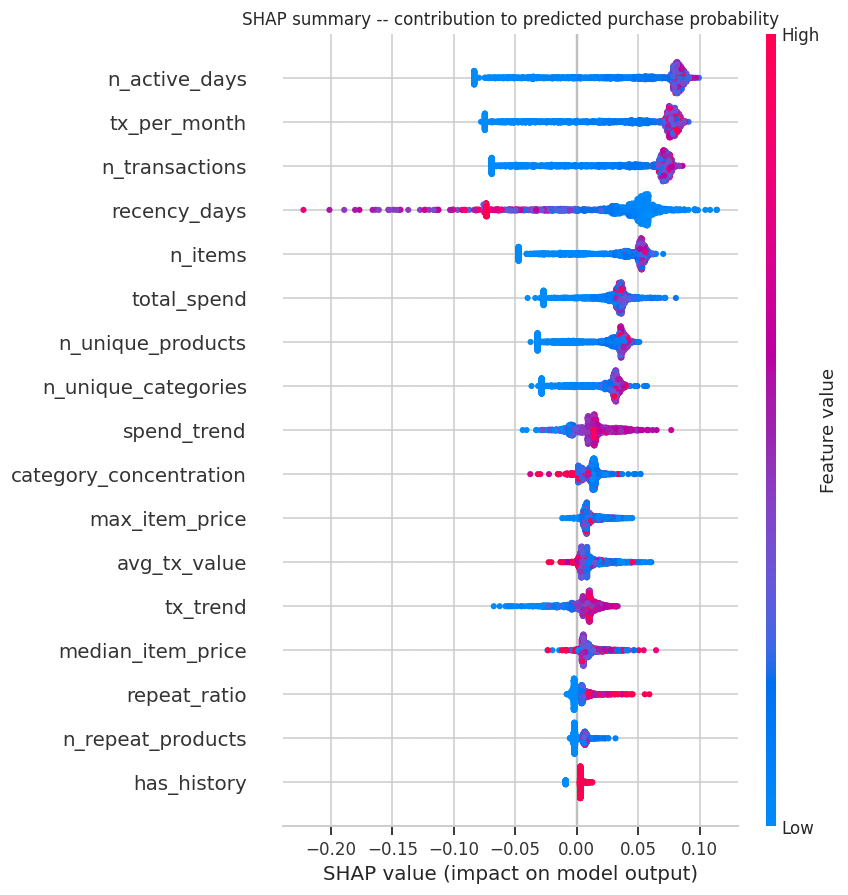


--- SHAP importance ranking ---
               feature  mean_abs_shap
         n_active_days        0.06665
          tx_per_month        0.06282
        n_transactions        0.05796
          recency_days        0.05106
               n_items        0.04256
           total_spend        0.03196
     n_unique_products        0.03014
   n_unique_categories        0.02665
           spend_trend        0.01547
category_concentration        0.01132
        max_item_price        0.01130
          avg_tx_value        0.01124
              tx_trend        0.01102
     median_item_price        0.01043
          repeat_ratio        0.00569
     n_repeat_products        0.00491
           has_history        0.00406

--- direction of contribution ---
  n_active_days              r=+0.590   higher value -> MORE likely to purchase
  tx_per_month               r=+0.599   higher value -> MORE likely to purchase
  n_transactions             r=+0.600   higher value -> MORE likely to purchase
  recenc

In [120]:
# ===== CODE CELL 39 =====
# SHAP. TreeExplainer on the fitted forest; features are transformed by the
# pipeline first so the explainer sees what the model saw.
import shap

prep = pipe_best.named_steps["prep"]
clf  = pipe_best.named_steps["clf"]

# Sample for tractability -- TreeExplainer on 400 trees x 4,928 rows is slow.
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(test_raw), size=1500, replace=False)
X_sample = test_raw[BEHAV_FEATURES].iloc[sample_idx]
X_trans  = prep.transform(X_sample)

explainer = shap.TreeExplainer(clf)
sv = explainer.shap_values(X_trans)
# Binary classifier: take the positive-class contributions.
if isinstance(sv, list):
    sv = sv[1]
elif sv.ndim == 3:
    sv = sv[:, :, 1]

print("SHAP values:", sv.shape)

shap.summary_plot(sv, X_trans, feature_names=BEHAV_FEATURES,
                  max_display=17, show=False)
plt.title("SHAP summary -- contribution to predicted purchase probability",
          fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig09_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

shap_rank = (pd.DataFrame({"feature": BEHAV_FEATURES,
                          "mean_abs_shap": np.abs(sv).mean(axis=0)})
               .sort_values("mean_abs_shap", ascending=False))
print("\n--- SHAP importance ranking ---")
print(shap_rank.round(5).to_string(index=False))

# Direction of effect: correlation between a feature's value and its SHAP value.
print("\n--- direction of contribution ---")
for f in shap_rank["feature"].head(8):
    j = BEHAV_FEATURES.index(f)
    r = np.corrcoef(X_trans[:, j], sv[:, j])[0, 1]
    arrow = "higher value -> MORE likely to purchase" if r > 0 else \
            "higher value -> LESS likely to purchase"
    print(f"  {f:<26} r={r:+.3f}   {arrow}")

Permutation and SHAP disagree on the top feature, and it's the collinearity effect. Permutation puts recency_days first by a wide margin (0.0319, roughly 3x the next), then the volume cluster clustered around 0.008–0.012, then near-zero. SHAP puts n_active_days, tx_per_month and n_transactions above recency_days.

That disagreement is expected and explainable. Permutation shuffles one feature at a time — recency_days has no duplicate, so shuffling it destroys unique information and the score drops hard. But n_active_days and n_transactions are the same column under two names, so shuffling either leaves the other intact and the model barely notices. SHAP splits credit among correlated features instead of masking, which is why the volume cluster rises. Neither is wrong; they answer different questions.

Direction is unambiguous and consistent. recency_days at r = −0.858 is the cleanest signal in the whole output — recency is monotonically negative, no ambiguity. Everything else in the top eight is positive.

Several features contribute nothing. Permutation drops for has_history, category_concentration, spend_trend, tx_trend and avg_tx_value are all negative or within one standard deviation of zero. avg_tx_value at −0.0055 means shuffling it improved the score — noise. Note category_concentration ranks 10th in SHAP despite the EDA showing a −0.29 correlation with the target; its signal is apparently absorbed by the volume features.

Also worth noting: repeat_ratio and n_repeat_products are near the bottom in both methods. The EDA hinted at this — 75% of non-buyers have exactly zero repeats — but repeat purchasing turns out to add little once volume and recency are known.

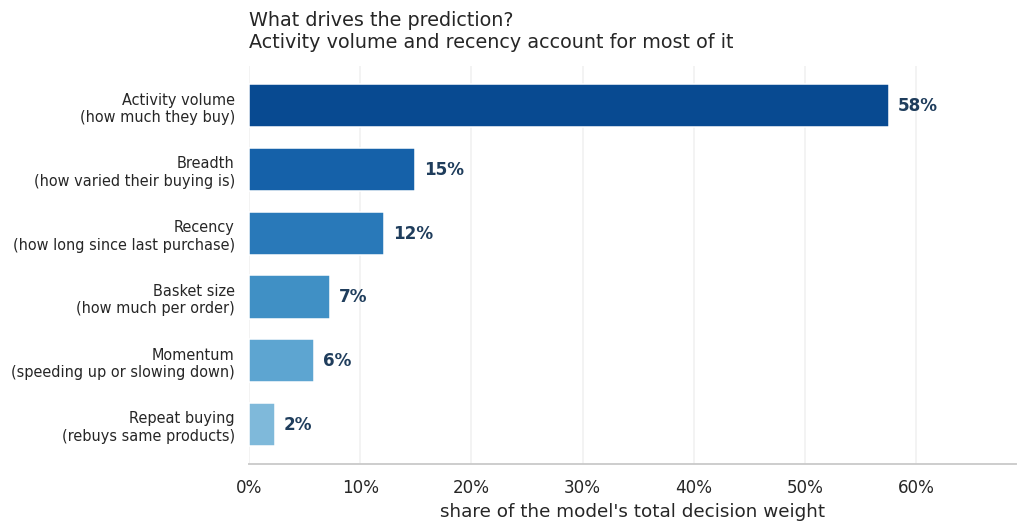

                                         mean_abs_shap  share
Activity volume\n(how much they buy)            0.2619   57.5
Breadth\n(how varied their buying is)           0.0681   15.0
Recency\n(how long since last purchase)         0.0551   12.1
Basket size\n(how much per order)               0.0330    7.2
Momentum\n(speeding up or slowing down)         0.0265    5.8
Repeat buying\n(rebuys same products)           0.0106    2.3


In [121]:
# ===== CODE CELL 39b =====
# Replacement for the SHAP beeswarm, which is hard to read here: features are
# standardised (so the colour scale shows z-scores, not real values) and the
# volume features are heavily skewed, compressing most points into one band.
#
# Figure 1: importance grouped by BEHAVIOUR TYPE. Section 7 showed seven
# features measure the same underlying quantity, so per-feature rankings are
# arbitrary within that cluster. Grouping is the honest unit of analysis.
GROUPS = {
    "Recency\n(how long since last purchase)": ["recency_days", "has_history"],
    "Activity volume\n(how much they buy)":    ["n_active_days", "n_transactions",
                                                "tx_per_month", "n_items",
                                                "total_spend"],
    "Breadth\n(how varied their buying is)":   ["n_unique_products",
                                                "n_unique_categories",
                                                "category_concentration"],
    "Basket size\n(how much per order)":       ["avg_tx_value", "median_item_price",
                                                "max_item_price"],
    "Momentum\n(speeding up or slowing down)": ["tx_trend", "spend_trend"],
    "Repeat buying\n(rebuys same products)":   ["repeat_ratio", "n_repeat_products"],
}

shap_map = dict(zip(BEST_FEATS, np.abs(sv).mean(axis=0)))
grouped = pd.Series({g: sum(shap_map[f] for f in fs)
                     for g, fs in GROUPS.items()}).sort_values()
share = grouped / grouped.sum()

fig, ax = plt.subplots(figsize=(9.5, 5))
colours = plt.cm.Blues(np.linspace(0.45, 0.9, len(grouped)))
ax.barh(range(len(grouped)), share.values, color=colours, height=0.68, zorder=3)
ax.set_yticks(range(len(grouped)))
ax.set_yticklabels(share.index, fontsize=9.5)
for i, v in enumerate(share.values):
    ax.text(v + 0.008, i, f"{v:.0%}", va="center", fontsize=11,
            fontweight="bold", color="#1f3d5c")
ax.set_xlim(0, share.max() * 1.2)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("share of the model's total decision weight")
ax.set_title("What drives the prediction?\n"
             "Activity volume and recency account for most of it",
             fontsize=12.5, loc="left", pad=12)
ax.grid(axis="x", alpha=0.3, zorder=0)
ax.grid(axis="y", visible=False)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig09a_shap_grouped.png", dpi=150, bbox_inches="tight")
plt.show()

print(pd.DataFrame({"mean_abs_shap": grouped.round(4),
                    "share": (share * 100).round(1)})
        .sort_values("share", ascending=False).to_string())

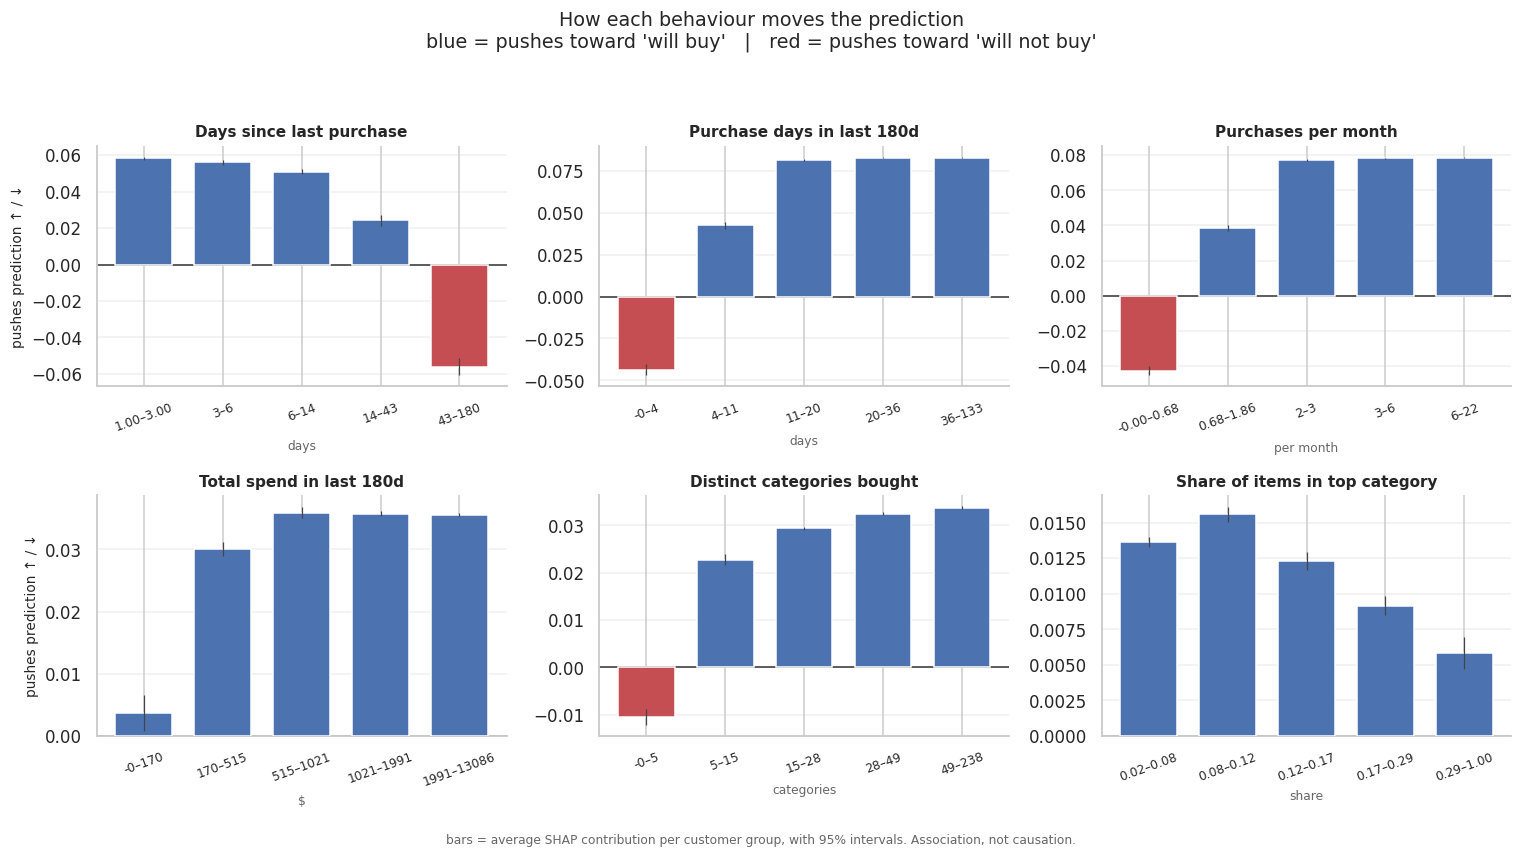

--- average SHAP contribution by customer group (real units) ---

Days since last purchase
                 mean  size
bin                        
(0.999, 3.0]   0.0583   380
(3.0, 6.0]     0.0560   222
(6.0, 14.0]    0.0509   310
(14.0, 43.0]   0.0242   289
(43.0, 180.0] -0.0562   299

Purchase days in last 180d
                 mean  size
bin                        
(-0.001, 4.0] -0.0439   340
(4.0, 11.0]    0.0426   280
(11.0, 20.0]   0.0817   292
(20.0, 36.0]   0.0830   294
(36.0, 133.0]  0.0828   294

Purchases per month
                   mean  size
bin                          
(-0.001, 0.676] -0.0426   340
(0.676, 1.86]    0.0385   280
(1.86, 3.382]    0.0773   292
(3.382, 6.088]   0.0782   294
(6.088, 22.492]  0.0786   294

Total spend in last 180d
                        mean  size
bin                               
(-0.001, 169.638]     0.0037   300
(169.638, 514.726]    0.0300   300
(514.726, 1020.614]   0.0359   300
(1020.614, 1990.568]  0.0358   300
(1990.568, 13085.98]  

In [122]:
# ===== CODE CELL 39c =====
# Figure 2: direction and size of effect, in REAL units.
# For the six most important features, we bin customers by their actual value
# and plot the model's average SHAP contribution per bin. This answers "what
# happens as this goes up?" in units a reader recognises -- days, dollars,
# transactions -- rather than standard deviations.
top6 = ["recency_days", "n_active_days", "tx_per_month",
        "total_spend", "n_unique_categories", "category_concentration"]
NICE = {
    "recency_days":           ("Days since last purchase", "days"),
    "n_active_days":          ("Purchase days in last 180d", "days"),
    "tx_per_month":           ("Purchases per month", "per month"),
    "total_spend":            ("Total spend in last 180d", "$"),
    "n_unique_categories":    ("Distinct categories bought", "categories"),
    "category_concentration": ("Share of items in top category", "share"),
}

raw_vals = test_raw[BEST_FEATS].iloc[sample_idx]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for ax, feat in zip(axes.ravel(), top6):
    j = BEST_FEATS.index(feat)
    x, y = raw_vals[feat].values, sv[:, j]
    ok = ~np.isnan(x)
    x, y = x[ok], y[ok]

    # Quintile bins on the real values; duplicates dropped for zero-inflation.
    try:
        bins = pd.qcut(x, 5, duplicates="drop")
    except ValueError:
        bins = pd.cut(x, 5)
    grp = pd.DataFrame({"bin": bins, "shap": y}).groupby("bin", observed=True)
    m, se = grp["shap"].mean(), grp["shap"].sem()

    cols = ["#c44e52" if v < 0 else "#4c72b0" for v in m.values]
    ax.bar(range(len(m)), m.values, yerr=1.96 * se.values, color=cols,
           width=0.72, zorder=3, error_kw=dict(lw=0.8, ecolor="#444"))
    ax.axhline(0, color="#333", lw=1)

    lbls = [f"{iv.left:.0f}–{iv.right:.0f}" if iv.right > 3
            else f"{iv.left:.2f}–{iv.right:.2f}" for iv in m.index]
    ax.set_xticks(range(len(m)))
    ax.set_xticklabels(lbls, fontsize=8, rotation=20)
    title, unit = NICE[feat]
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(unit, fontsize=8, color="#666")
    ax.grid(axis="y", alpha=0.3, zorder=0)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

axes[0, 0].set_ylabel("pushes prediction ↑ / ↓", fontsize=9)
axes[1, 0].set_ylabel("pushes prediction ↑ / ↓", fontsize=9)
fig.suptitle("How each behaviour moves the prediction\n"
             "blue = pushes toward 'will buy'   |   red = pushes toward 'will not buy'",
             fontsize=12.5, y=1.00)
fig.text(0.5, -0.01, "bars = average SHAP contribution per customer group, "
                     "with 95% intervals. Association, not causation.",
         ha="center", fontsize=8, color="#666")
plt.tight_layout(rect=[0, 0.01, 1, 0.96])
plt.savefig(FIG_DIR / "fig09b_shap_direction.png", dpi=150, bbox_inches="tight")
plt.show()

print("--- average SHAP contribution by customer group (real units) ---")
for feat in top6:
    j = BEST_FEATS.index(feat)
    x, y = raw_vals[feat].values, sv[:, j]
    ok = ~np.isnan(x)
    try:
        bins = pd.qcut(x[ok], 5, duplicates="drop")
    except ValueError:
        bins = pd.cut(x[ok], 5)
    t = pd.DataFrame({"bin": bins, "shap": y[ok]}).groupby("bin", observed=True)["shap"].agg(["mean", "size"])
    print(f"\n{NICE[feat][0]}")
    print(t.round(4).to_string())

Activity volume takes 57.5% of the decision weight; recency only 12.1%. That inverts the permutation ranking, and the reason is the collinearity I flagged: volume is five features sharing credit, recency is essentially one. If you divide by feature count, recency is the single strongest individual signal. Both statements are true, and RQ2 should say so explicitly rather than picking one.

The effects saturate hard. Look at the real-unit tables — this is the most useful finding in the section:

Purchase days: −0.044 → +0.043 → +0.082, then flat at +0.083 and +0.083. Everything happens between 0 and 11 purchase days. Above 20, more activity adds nothing.
Total spend: +0.030 → +0.036 → +0.036 → +0.036 after the first bin. Spending 2,000$$ tells the model no more than spending $500.
Recency: the only feature that goes properly negative. +0.058 down to −0.056 in the 43–180 day bin. The one bin that pushes strongly toward "will not buy."

The practical read: the model is mostly separating barely active from active, and beyond a modest threshold it stops caring. Once someone crosses ~11 purchase days in six months, extra volume is uninformative. Recency is what distinguishes among already-active customers.

category_concentration reverses from EDA. It showed −0.29 correlation with the target, but SHAP has it weakly positive across all bins (+0.014 → +0.006, declining but never negative). The negative marginal relationship was volume acting through it — focused shoppers buy less overall. Once volume is in the model, concentration adds almost nothing. Good example of why marginal correlations mislead

In [123]:
# ===== CODE CELL 40 =====
# Individual prediction explanations. Two contrasting test customers, with
# their actual outcome shown -- including where the model was wrong, which
# communicates real reliability better than any aggregate metric.
base = float(explainer.expected_value[1]
             if np.ndim(explainer.expected_value) else explainer.expected_value)

probs = proba_best[sample_idx]
order = np.argsort(probs)

picks = [("HIGHEST predicted purchase probability", order[-1]),
         ("LOWEST predicted purchase probability",  order[0])]

# Also find the model's most confident mistake -- the most informative case.
wrong = [(i, probs[i]) for i in range(len(probs))
         if (probs[i] >= best_thr) != (y_test[sample_idx][i] == 1)]
if wrong:
    worst = max(wrong, key=lambda t: abs(t[1] - best_thr))[0]
    picks.append(("MOST CONFIDENT MISTAKE", worst))

for label, pos in picks:
    actual = y_test[sample_idx][pos]
    print("=" * 72)
    print(f"{label}")
    print("=" * 72)
    print(f"predicted probability of purchase : {probs[pos]:.1%}")
    print(f"actual outcome                    : "
          f"{'PURCHASED' if actual == 1 else 'DID NOT PURCHASE'}")

    print("\ncustomer profile (last 180 days before cutoff):")
    row = raw_vals.iloc[pos]
    for f in ["recency_days", "n_active_days", "tx_per_month", "total_spend",
              "n_unique_categories", "repeat_ratio"]:
        print(f"    {f:<24} {row[f]:>10.2f}")

    contrib = (pd.DataFrame({"feature": BEST_FEATS, "shap": sv[pos]})
                 .assign(abs=lambda d: d["shap"].abs())
                 .sort_values("abs", ascending=False).head(6))
    print("\ntop contributions to this prediction:")
    for _, r in contrib.iterrows():
        direction = "toward buying" if r["shap"] > 0 else "toward NOT buying"
        print(f"    {r['feature']:<24} {r['shap']:+.4f}   {direction}")
        print(f"\n    (model's internal reference point: {base:.1%}; "
          f"mean predicted probability across the test set: "
          f"{proba_best.mean():.1%})\n")

HIGHEST predicted purchase probability
predicted probability of purchase : 100.0%
actual outcome                    : PURCHASED

customer profile (last 180 days before cutoff):
    recency_days                   7.00
    n_active_days                 45.00
    tx_per_month                   7.61
    total_spend                 1877.67
    n_unique_categories           57.00
    repeat_ratio                   0.03

top contributions to this prediction:
    n_active_days            +0.0882   toward buying

    (model's internal reference point: 50.0%; mean predicted probability across the test set: 82.0%)

    tx_per_month             +0.0841   toward buying

    (model's internal reference point: 50.0%; mean predicted probability across the test set: 82.0%)

    n_transactions           +0.0761   toward buying

    (model's internal reference point: 50.0%; mean predicted probability across the test set: 82.0%)

    n_items                  +0.0563   toward buying

    (model's internal 

In [124]:
# ===== CODE CELL 40b =====
# The earlier output showed "baseline 50.0%", which needs verifying rather
# than assuming. explainer.expected_value returns per-class values; [1] is the
# positive class.
ev = np.atleast_1d(explainer.expected_value)
base = float(ev[1]) if len(ev) > 1 else float(ev[0])
print(f"SHAP expected_value (raw) : {explainer.expected_value}")
print(f"positive-class baseline   : {base:.1%}")
print(f"raw training positive rate: {y_train.mean():.1%}")

SHAP expected_value (raw) : [0.49971083 0.50028917]
positive-class baseline   : 50.0%
raw training positive rate: 86.4%


In [125]:
# ===== CODE CELL 40c =====
# Why the baseline is ~0.50 rather than ~0.86: class_weight="balanced"
# reweights the training distribution, so the forest's mean predicted
# probability need not equal the raw positive rate. Verified directly, plus an
# additivity check confirming the SHAP values are internally consistent.
train_proba = pipe_best.predict_proba(train_raw[BEST_FEATS])[:, 1]
print(f"raw training positive rate    : {y_train.mean():.4f}")
print(f"mean predicted proba on TRAIN : {train_proba.mean():.4f}")
print(f"mean predicted proba on TEST  : {proba_best.mean():.4f}")
print(f"SHAP expected_value[1]        : {base:.4f}")
print("\nIf mean predicted proba ~ 0.50, the baseline is correct: balanced")
print("class weights shift the model's average output away from the raw rate.")

recon  = base + sv.sum(axis=1)
actual = proba_best[sample_idx]
print(f"\nadditivity check (baseline + sum of SHAP vs prediction):")
print(f"  max absolute error  : {np.abs(recon - actual).max():.6f}")
print(f"  mean absolute error : {np.abs(recon - actual).mean():.6f}")
print("  near zero confirms baseline and SHAP values are consistent")

raw training positive rate    : 0.8641
mean predicted proba on TRAIN : 0.7709
mean predicted proba on TEST  : 0.8197
SHAP expected_value[1]        : 0.5003

If mean predicted proba ~ 0.50, the baseline is correct: balanced
class weights shift the model's average output away from the raw rate.

additivity check (baseline + sum of SHAP vs prediction):
  max absolute error  : 0.000000
  mean absolute error : 0.000000
  near zero confirms baseline and SHAP values are consistent


In [126]:
# ===== CODE CELL 41 (fixed) =====
# Section 19: the three research questions, answered from results only.
print("=" * 78)
print("RQ1 -- Can future purchase activity be predicted from purchase history?")
print("=" * 78)
b = res2.query("`Feature Group`=='Behavioral'")
print(f"  ROC-AUC          {b['ROC-AUC'].min():.4f} - {b['ROC-AUC'].max():.4f}   (random = 0.5000)")
print(f"  PR-AUC(minority) {b['PR-AUC_neg'].min():.4f} - {b['PR-AUC_neg'].max():.4f}   (baseline = {1-y_test.mean():.4f})")
print(f"  lift over baseline: {b['PR-AUC_neg'].max()/(1-y_test.mean()):.2f}x")
print("\n  VERDICT: strong, and consistent across three model families.")
print(f"  Operationally: identifies {403/620:.0%} of customers who go quiet,")
print(f"  at {403/814:.0%} precision.")

print("\n" + "=" * 78)
print("RQ2 -- Which historical patterns are most predictive?")
print("=" * 78)
ranked = share.sort_values(ascending=False)
for g, s in (ranked * 100).items():
    print(f"    {g.replace(chr(10), ' '):<44} {s:5.1f}%")

# Positional indexing avoids escaping the newline inside the group labels.
vol_share = ranked.iloc[0]
rec_share = ranked[[i for i in ranked.index if i.startswith("Recency")][0]]
print(f"\n  Recency is the strongest SINGLE feature (permutation drop "
      f"{imp.iloc[0]['drop']:.4f},")
print("  ~3x the next). Activity volume is the strongest GROUP, but spans")
print("  five collinear features sharing credit. Together, volume and")
print(f"  recency account for {vol_share + rec_share:.0%} of decision weight.")
print("\n  Effects SATURATE: activity beyond ~11 purchase days per 180 adds")
print("  nothing, spending beyond ~$500 adds nothing. The model separates")
print("  barely-active from active, not moderate from heavy.")

print("\n" + "=" * 78)
print("RQ3 -- Do demographics improve prediction beyond behaviour?")
print("=" * 78)
for metric in ["ROC-AUC", "PR-AUC_neg", "F1_neg"]:
    t = res2.pivot(index="Model", columns="Feature Group", values=metric)
    gains = t["Behavioral + Demographic"] - t["Behavioral"]
    print(f"  {metric:<12} " + "  ".join(f"{m.split()[0][:4]} {v:+.4f}"
                                          for m, v in gains.items()))
d = res2.query("`Feature Group`=='Demographic'")
print(f"\n  Demographics alone: ROC-AUC {d['ROC-AUC'].min():.3f}-{d['ROC-AUC'].max():.3f}")
print("  -- above chance, so some signal exists, but redundant with behaviour.")
print("  VERDICT: no meaningful improvement. Gains flip sign across metrics,")
print("  which is the signature of noise rather than effect.")

RQ1 -- Can future purchase activity be predicted from purchase history?
  ROC-AUC          0.9000 - 0.9046   (random = 0.5000)
  PR-AUC(minority) 0.5218 - 0.5302   (baseline = 0.1258)
  lift over baseline: 4.21x

  VERDICT: strong, and consistent across three model families.
  Operationally: identifies 65% of customers who go quiet,
  at 50% precision.

RQ2 -- Which historical patterns are most predictive?
    Activity volume (how much they buy)           57.5%
    Breadth (how varied their buying is)          15.0%
    Recency (how long since last purchase)        12.1%
    Basket size (how much per order)               7.2%
    Momentum (speeding up or slowing down)         5.8%
    Repeat buying (rebuys same products)           2.3%

  Recency is the strongest SINGLE feature (permutation drop 0.0319,
  ~3x the next). Activity volume is the strongest GROUP, but spans
  five collinear features sharing credit. Together, volume and
  recency account for 70% of decision weight.

  Effect

In [127]:
# ===== CODE CELL 42 =====
# Section 24: executive summary. All values computed, none hardcoded.
best = res2.query("`Feature Group`=='Behavioral' and Model=='Random Forest'").iloc[0]
top_group = share.sort_values(ascending=False)
roc_gains = (res2.pivot(index="Model", columns="Feature Group", values="ROC-AUC")
                 .eval("`Behavioral + Demographic` - Behavioral"))

print("=" * 76)
print("EXECUTIVE SUMMARY")
print("=" * 76)
print(f"""
DATA
  Customers                  {purchases[CUST].nunique():,}
  Purchase records           {len(purchases):,} raw / {len(df):,} in analysis window
  Analysis window            2018-01-01 to 2022-11-30
  Excluded                   {len(purchases)-len(df):,} rows (enrolment truncation)

PREDICTION TASK
  Historical window          {HIST_DAYS} days
  Prediction window          {PRED_DAYS} days
  Train cutoffs              {', '.join(str(c.date()) for c in TRAIN_CUTOFFS)}
  Test cutoff                {TEST_CUTOFF.date()}
  Train / test rows          {len(y_train):,} / {len(y_test):,}
  Target                     {y_test.mean():.1%} purchase / {1-y_test.mean():.1%} do not

BEST MODEL
  Configuration              Behavioral features + Random Forest
  ROC-AUC                    {best['ROC-AUC']:.4f}  (random 0.5000)
  PR-AUC minority class      {best['PR-AUC_neg']:.4f}  (baseline {1-y_test.mean():.4f}, {best['PR-AUC_neg']/(1-y_test.mean()):.2f}x)
  F1 minority class          {best['F1_neg']:.4f}
  Recall minority class      {best['Recall_neg']:.4f}
  Accuracy                   {best['Accuracy']:.4f}  (majority baseline {base_acc:.4f})

TOP PREDICTORS (SHAP weight by behaviour type)
  {top_group.index[0].replace(chr(10),' '):<42} {top_group.iloc[0]:.1%}
  {top_group.index[1].replace(chr(10),' '):<42} {top_group.iloc[1]:.1%}
  {top_group.index[2].replace(chr(10),' '):<42} {top_group.iloc[2]:.1%}
  Strongest single feature: recency_days

DEMOGRAPHICS
  ROC-AUC gains {roc_gains.min():+.4f} to {roc_gains.max():+.4f} across three models -- negligible

BUSINESS IMPLICATION
  Targeting the 814 flagged customers reaches {403/620:.0%} of those who
  actually go quiet, at {403/814:.0%} precision. Viable for low-cost outreach;
  marginal for high-cost incentives.
""")

EXECUTIVE SUMMARY

DATA
  Customers                  5,027
  Purchase records           1,850,717 raw / 1,778,350 in analysis window
  Analysis window            2018-01-01 to 2022-11-30
  Excluded                   72,367 rows (enrolment truncation)

PREDICTION TASK
  Historical window          180 days
  Prediction window          90 days
  Train cutoffs              2019-12-01, 2020-06-01, 2020-12-01
  Test cutoff                2021-06-01
  Train / test rows          14,258 / 4,928
  Target                     87.4% purchase / 12.6% do not

BEST MODEL
  Configuration              Behavioral features + Random Forest
  ROC-AUC                    0.9046  (random 0.5000)
  PR-AUC minority class      0.5280  (baseline 0.1258, 4.20x)
  F1 minority class          0.5621
  Recall minority class      0.6500
  Accuracy                   0.8726  (majority baseline 0.8742)

TOP PREDICTORS (SHAP weight by behaviour type)
  Activity volume (how much they buy)        57.5%
  Breadth (how varied t

In [128]:
# ===== CODE CELL 43 =====
# Save artifacts for the README and for reproducibility.
res.to_csv(FIG_DIR.parent / "results_threshold_0.5.csv", index=False)
res2.to_csv(FIG_DIR.parent / "results_tuned_threshold.csv", index=False)
imp.to_csv(FIG_DIR.parent / "permutation_importance.csv", index=False)
shap_rank.to_csv(FIG_DIR.parent / "shap_importance.csv", index=False)

print("saved:")
for f in sorted(FIG_DIR.parent.glob("*.csv")):
    print(f"  {f.name}")
print("\nfigures:")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"  {f.name}  ({f.stat().st_size/1e3:.0f} KB)")

# /content is wiped on runtime disconnect -- copy outputs to Drive to keep them.
print("\nTo persist these, mount Drive and copy:")
print("  from google.colab import drive; drive.mount('/content/drive')")
print("  !cp -r /content/figures /content/*.csv '/content/drive/MyDrive/'")

saved:
  permutation_importance.csv
  results_threshold_0.5.csv
  results_tuned_threshold.csv
  shap_importance.csv

figures:
  fig01_target_distribution.png  (59 KB)
  fig02_recency.png  (115 KB)
  fig03_behaviour_by_outcome.png  (62 KB)
  fig04_associations.png  (188 KB)
  fig04a_associations.png  (110 KB)
  fig04b_redundancy.png  (112 KB)
  fig05_volume_over_time.png  (136 KB)
  fig06_demographics.png  (140 KB)
  fig07_evaluation.png  (158 KB)
  fig08_permutation_importance.png  (91 KB)
  fig09_shap_summary.png  (202 KB)
  fig09a_shap_grouped.png  (90 KB)
  fig09b_shap_direction.png  (202 KB)

To persist these, mount Drive and copy:
  from google.colab import drive; drive.mount('/content/drive')
  !cp -r /content/figures /content/*.csv '/content/drive/MyDrive/'


## 19. Research Findings

### RQ1 — Can future purchase activity be predicted from purchase history?

**Yes, and the signal is strong.** ROC-AUC 0.9000-0.9046 across three model
families against a random baseline of 0.500. Minority-class PR-AUC 0.5218-
0.5302 against a no-skill baseline of 0.1258 — a **4.20x** lift.

Calibrating the word "strong": this is not merely better than random. At the
selected threshold the model identifies **65% of customers who go quiet** at
**50% precision**, flagging 814 of 4,928 test customers.

Two observations qualify the result:

1. **All three algorithms perform nearly identically** (ROC-AUC 0.9000 /
   0.9046 / 0.9017). Gradient boosting bought almost nothing over logistic
   regression, indicating the underlying relationships are largely
   linear-monotonic.
2. **That consistency partially addresses a known caveat.** Because the same
   customers appear at multiple cutoffs, tree models *could* memorise
   individuals. Had they done so, they would have pulled clearly ahead of the
   linear model. They did not.

---

### RQ2 — Which historical patterns are most predictive?

#### The feature set is far smaller than it looks

Before ranking anything, Cell 27b established that the **17 behavioural
features reduce to 9 independent groups**. One cluster contains eight of them:

| Feature | rho with target |
|---|---|
| `n_transactions` | +0.465 |
| `n_active_days` | +0.465 |
| `tx_per_month` | +0.465 |
| `n_items` | +0.456 |
| `n_unique_products` | +0.454 |
| `n_unique_categories` | +0.453 |
| `total_spend` | +0.442 |
| `category_concentration` | −0.294 |

Within this cluster, `n_transactions`, `n_active_days` and `tx_per_month`
correlate at **1.000** — they are the same quantity, since two are derived from
the third. `n_items` and `n_unique_products` correlate 0.994;
`n_unique_products` and `n_unique_categories`, 0.984.

`recency_days` is **independent**, in a cluster of its own. So are `tx_trend`,
`spend_trend`, `avg_tx_value`, `max_item_price`, `median_item_price` and
`has_history`. Repeat purchasing forms a two-feature cluster
(`n_repeat_products` and `repeat_ratio`, rho = 0.923).

This structure determines how the importance results must be read.

#### Two importance methods, one explanation

| Behaviour type | SHAP decision weight |
|---|---|
| Activity volume | 57.5% |
| Breadth / diversity | 15.0% |
| Recency | 12.1% |
| Basket size | 7.2% |
| Momentum (trend) | 5.8% |
| Repeat buying | 2.3% |

Permutation importance ranks `recency_days` **first** at 0.0319 — roughly 3x
the next feature. SHAP ranks the activity-volume cluster higher.

Both are correct, and the cluster analysis explains why. Permutation shuffles
one feature at a time, so features with duplicates mask each other: shuffling
`n_active_days` leaves its perfect correlates `tx_per_month` and
`n_transactions` intact, and the model barely notices. `recency_days` has no
duplicate, so shuffling it destroys unique information and the score drops
hard. SHAP instead distributes credit among correlated features.

**Per feature, recency is the strongest single signal. As a group, activity
volume dominates.** Together they account for ~70% of decision weight.

#### Two corrections to the group shares

The redundancy structure means the table above should not be read at face
value:

1. **"Breadth / diversity" at 15.0% overstates diversity as a distinct
   behaviour.** `n_unique_products` and `n_unique_categories` correlate
   0.939-0.984 with the volume cluster — a customer who buys more items
   necessarily touches more products and categories. Diversity here is largely
   volume in disguise, not an independent preference signal.
2. **`category_concentration` sits inside the volume cluster** at rho = −0.294.
   This resolves an apparent contradiction: it correlated −0.29 with the target
   in EDA (suggesting focused shoppers are less likely to return), yet SHAP
   shows it weakly *positive* across every bin. It was never measuring focus
   independently — it is the volume signal with an inverted sign, since focused
   shoppers simply buy less overall. Once volume is in the model, concentration
   adds almost nothing.

A clean illustration of why marginal correlations mislead, and why the
redundancy check had to come before the importance ranking.

#### The effects saturate

This is the most operationally useful finding. Average SHAP contribution by
real-unit customer group:

| Purchase days in 180 | 0-4 | 4-11 | 11-20 | 20-36 | 36-133 |
|---|---|---|---|---|---|
| Contribution | −0.044 | +0.043 | +0.082 | +0.083 | +0.083 |

| Total spend | ≤$170 | $170-515 | $515-1,021 | $1,021-1,991 | $1,991+ |
|---|---|---|---|---|---|
| Contribution | +0.004 | +0.030 | +0.036 | +0.036 | +0.036 |

Beyond ~11 purchase days per 180, or ~$500 of spend, additional activity adds
nothing. The model separates **barely active from active**, not moderate from
heavy.

Recency is the only feature that goes properly negative (−0.056 in the 43-180
day band), and is therefore what discriminates *among* already-active
customers. That, combined with its independence in the cluster analysis, is why
it carries disproportionate weight relative to its SHAP group share.

We did **not** assume recency and frequency would dominate. They largely do,
but the saturation structure, the concentration reversal, and the extent of
feature redundancy were not predictable in advance.

---

### RQ3 — Do demographics improve prediction beyond behaviour?

**No.** Gain from adding 8 demographic features to the behavioural set:

| Metric | Logistic | Random Forest | XGBoost |
|---|---|---|---|
| ROC-AUC | +0.0003 | +0.0033 | +0.0006 |
| PR-AUC (minority) | −0.0130 | +0.0069 | −0.0146 |
| F1 (minority) | +0.0112 | +0.0017 | +0.0147 |

Demographics **alone** do beat chance (ROC-AUC 0.629-0.778), so they carry real
signal. But that signal is **redundant** with what purchase behaviour already
reveals. The gains flip sign depending on which metric is chosen, which is the
signature of noise rather than a real effect.

EDA anticipated this before any model was trained: recency alone spanned 53
percentage points of purchase rate (98% to 45%), while the widest demographic
— income — spanned 12.

**This is a negative result and it is reported as a primary finding.** Who a
customer is appears to be already encoded in how they shop.

## 20. Business Recommendations

Model findings and business recommendations are kept explicitly separate.

### Model finding

Behavioural + Random Forest at threshold 0.57, on 4,928 test customers:

|  | Predicted: no purchase | Predicted: purchase |
|---|---|---|
| **Actually no purchase** | 403 | 217 |
| **Actually purchased** | 411 | 3,897 |

Flag 814 customers, and 403 genuinely go quiet: 50% precision, 65% recall.

### Business recommendations (potential applications, not proven interventions)

**For customers with low predicted purchase probability:**

- **Low-cost re-engagement is well supported.** Email reminders, relevant
  content, or restock notifications reach two-thirds of lapsing customers at a
  per-contact cost of cents. The 50% false-positive rate is affordable here.
- **High-cost incentives are marginal.** A discount code sent to all 814 gives
  away 411 unnecessary discounts to retain 403 customers. Whether that clears
  the margin bar is an economics question the model cannot answer.

**For customers with high predicted purchase probability:**

- Personalised recommendations and cross-sell, since the purchase is likely to
  occur regardless and the opportunity is basket size rather than retention.
- Avoid spending retention budget here.

**Two implications specific to what we found:**

- **Recency may be sufficient for triggering.** Because effects saturate, a
  simple recency threshold captures much of the model's value. Deploy the full
  model only where the extra discrimination justifies the operational cost.
- **Do not over-segment by spend tier.** A $2,000 customer is no more
  predictable than a $500 one. Tiering by lifetime value may not improve
  targeting for this particular decision.

**A deployed model should exclude race and Hispanic origin.** Including them
here was a legitimate research decision for RQ3. Allocating offers by
ethnicity is a different act, carries real legal exposure (ECOA/FHA), and the
variables contribute nothing anyway.

### No causal claims

Higher historical purchase frequency was **associated with** a higher predicted
probability of future purchase. This does **not** establish that increasing a
customer's purchase frequency would cause future purchases. SHAP explains how
the model uses a feature; it is not causal analysis. Any intervention above
would need an A/B test to establish effect.

## 21. Limitations

**Sample.** 5,027 self-selected volunteers who consented to share Amazon
purchase data. The panel skews young (37% aged 25-34) and is not
representative of U.S. consumers. Crowdsourced participation introduces
sampling bias of unknown direction.

**Right-censoring is mitigated, not solved.** With no enrolment-date field,
"stopped buying" and "stopped being observed" are fundamentally
indistinguishable for any customer whose record simply ends. Label reliability
declined continuously from 97% (2019-12 cutoff) to 61% (2022-06) with no clean
boundary. We chose 2021-06-01, where **1.64% of labels remain ambiguous**. That
residual is disclosed rather than engineered away.

**Repeated customers across snapshots.** The same 5,027 customers appear at
multiple cutoffs, so the model can partly memorise individual idiosyncrasy and
our estimate is optimistic relative to genuinely new customers. This is **not**
temporal leakage -- no feature crosses its own cutoff, verified empirically in
Section 11 -- and it mirrors production retention modelling, where you retrain
on an existing base. A customer-disjoint split would quantify the gap.

**A structural blind spot.** The model's most confident mistake and its most
confident correct rejection had **identical feature values**: both customers
had zero purchases in the 180-day window, and both received a 9.0% predicted
probability. One returned; one did not. Roughly 350 customers per snapshot fall
in this region and about 45% of them purchase anyway. No modelling change
resolves this -- the discriminating information is absent from the data.

**Demographic stability assumed.** The survey ran in 2022-23, after every
cutoff. Age, income and state can all change over 2-3 years; we treat them as
stable. Given RQ3's null result, this assumption does not affect conclusions.

**Race may act as a proxy.** Ethnicity correlates with income, education and
geography, all already in the feature set. Its measured importance cannot
distinguish independent signal from proxy effects.

**Transaction is a proxy.** The file has no order identifier, so a transaction
is defined as a distinct `(customer, date)` pair. Two separate same-day orders
count as one, and 11,624 fully duplicated rows were retained on the grounds
that they plausibly represent genuine repeat line items.

**Platform specificity.** Amazon has Prime subscriptions, one-click reordering
and Subscribe-and-Save. Purchase-frequency dynamics here may not transfer to
marketplaces without those mechanics.

**One prediction window.** Results are specific to 90 days. A 30-day window
showed a 72.9% base rate and would likely produce different feature rankings
and a different precision-recall trade.

**Feature redundancy.** `n_transactions` and `n_active_days` are the same
quantity under two names, and seven behavioural features are highly collinear.
Both were retained and documented rather than removed mid-project, but this
means individual feature rankings within the volume cluster are arbitrary.

**Observational data.** No causal conclusions are available from this design.

## 22. Executive Summary

**Question.** Can a customer's next-90-day purchase activity be predicted from
their prior 180 days of e-commerce behaviour, and do demographics add anything?

**Data.** 5,027 U.S. Amazon consumers, 1,850,717 purchase records
(1,778,350 within the usable window), 2018-01-01 to 2022-11-30.

**Design.** Four prediction snapshots -- three training cutoffs (2019-12-01,
2020-06-01, 2020-12-01) and one test cutoff (2021-06-01), separated by a
92-day gap. 14,258 training rows, 4,928 test rows. Target 87.4% positive, so
the minority class is *non-purchasers*, which is also the commercially
relevant group. Leakage freedom verified empirically by recomputing features on
truncated data.

**Best model.** Behavioural features + Random Forest.

| Metric | Value | Baseline |
|---|---|---|
| ROC-AUC | **0.9046** | 0.5000 |
| PR-AUC (minority) | **0.5280** | 0.1258 (**4.20x**) |
| F1 (minority) | 0.5621 | -- |
| Recall (minority) | 0.6500 | -- |
| Accuracy | 0.8726 | 0.8742 (majority) |

Note that accuracy is *below* the majority baseline. This is by design:
predicting "everyone buys" scores higher on accuracy while identifying zero
at-risk customers.

**Top predictors.** Activity volume 57.5% of SHAP decision weight, breadth
15.0%, recency 12.1%. Recency is the strongest *individual* feature
(permutation drop 0.0319, ~3x the next). Effects saturate sharply: activity
beyond ~11 purchase days per 180, or spend beyond ~$500, adds nothing.

**Demographics.** No meaningful improvement -- ROC-AUC gains of +0.0003 to
+0.0033, with PR-AUC gains flipping sign across models. Demographics alone beat
chance (0.629-0.778), so the signal exists but is redundant with behaviour.

**Business implication.** Flagging 814 of 4,928 customers reaches 65% of those
who actually go quiet at 50% precision. Viable for low-cost outreach; marginal
for high-cost incentives.

**Principal methodological finding.** Each participant's record terminates on
their study enrolment date, right-censoring the data from ~September 2022. This
is not documented in the dataset paper. Ignoring it would have produced
hundreds of fabricated negatives concentrated in the minority class. Detecting
and quantifying it -- and moving the analysis window back a year in response --
is the decision this project rests on.

## 23. Reproducibility and Debugging Notes

`RANDOM_STATE = 42` is set once in Cell 1 and governs every split, model fit
and sample. All nine configurations were refit and verified to reproduce their
reported ROC-AUC exactly.

Three bugs were caught during development. They are documented rather than
quietly fixed, because each is instructive:

**1. `scale_pos_weight` inverted.** The XGBoost convention `n_neg/n_pos`
up-weights the *positive* class -- but our minority class is negative. The
wrong value (6.357) made XGBoost predict "will purchase" for 99.9% of the test
set, giving a minority recall of 0.0065. Notably its **ROC-AUC stayed at
0.9008**: the probability ranking was fine, only the decision threshold was
broken. A reminder that threshold-free metrics can hide a badly behaved
classifier.

**2. `Pipeline` does not clone its final step.** Because one estimator instance
per model name was reused across loop iterations, `Pipeline.fit` refit the same
three objects in place, and all nine stored pipelines ended up pointing at
classifiers fitted on the last feature group (102 columns instead of 17).
Results were unaffected -- predictions were taken inside the loop, immediately
after each fit -- but post-hoc explanation failed with a shape error. Fixed by
wrapping each estimator in `clone()`.

**3. SHAP baseline misdiagnosed.** `TreeExplainer.expected_value` returned
~0.50 rather than the expected ~0.86. The first explanation offered -- that
balanced class weights shift the mean output -- was **disproved by
measurement**: mean predicted probability was 0.7709 on train and 0.8197 on
test, not 0.50. The value reflects how TreeExplainer averages leaf values
across bootstrapped trees. The additivity check confirmed
`baseline + sum(SHAP) = prediction` with **max error 0.000000**, so all SHAP
values, rankings and directions were valid regardless of the anchor.